## SUPER PAC Analysis

### Basic Info

Names: Samuel Lewis, Jake Scott, Olivia Wright
Emails & UIDS:
Sam: u12277874@utah.edu (u12277874)
Jake: u1594325@utah.edu (u1594325)
Olivia: u1491584@utah (u1491584)

### Background and Motivation

**“There are two things that are important in politics. The first is money, and I can’t remember what the second one is.”** ― Mark Hanna, U.S. Senator from Ohio and former chairman of the Republican National Committee

Recently, political discourse has become increasingly heated with an increasing amount of money being used to influence elections. According to Anna Massoglia from the Brennan Center in 2025, Super PACs spending totaled 1.9 billion for the 2024 election cycle. A Super PAC is a committee that is allowed to spend unlimited funding support or opposing candidates as long as they don't directly work with the candidates. Traditionally, PAC spending was limited to 5000 per candidate. However, in the 2010 Supreme Court case Citizens United v. The Federal Election Commission, a decision was made that donations from PACs over 5000 are allowed if they do not go directly to the intended candidate. This carved out the way for Super PAsS where donations can be as large as possible but the money has to be used independently from the candidate. This leads us to the project, where we want to analyze these Super PACs with publicly available data from the FEC.


### Project Objectives

#### How much money do candidates in political parties receive opposing them and supporting them?
##### Benefits: learn something about the popularity of candidates among donors. Does success correlate with donations for or against?
#### Are supporting or opposing donations bigger?  More common?  Etc
##### Benefits: know how donations  from these pacs are primarily being used.
#### What are the biggest Super PACs donating? Where do they primarily donate and generally how do they lean politically?
##### Benefits: know more about how these Super PACs operate
#### Which political parties receive larger single donations, or donations from a single group?  Which receives smaller donations?
##### Benefits: know whether a party receives financial support from more individual donations while overshadowed by larger contributors.
#### Does the size of a donation correlate with Republican or Democrat?
##### Benefits: know which party is financially advantaged.
#### What effect do these donations have on the current Senate?
##### Benefit: understand how donations and financial support contribute to positions held.
#### What are the differences in expenditures within swing states?
##### Benefit: learn if swing states take more money or are "battlegrounds" for Super PACs



### Data Acquisition
We will be downloading our data as a CSV file from the federal election commission __[here](https://www.fec.gov/files/bulk-downloads/2024/independent_expenditure_2024.csv)__. We also got a list of senate seats from https://www.senate.gov/senators/.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from IPython.display import IFrame
import numpy as np
from sklearn.covariance import graphical_lasso
import matplotlib.pyplot as plt
import plotly.express as px

expendituresDataFrame = pd.read_csv("independentExpenditures2024.csv")
expendituresDataFrame.head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt
0,H4CO08034,"Evans, Gabe",C00866517,Go America PAC,G,CO,8.0,H,REPUBLICAN PARTY,9000.00,...,texts supporting Gabe Evans CO-8,TTHM.com,1845617,N,E2D2833410CAA40CB9A5,202410319719900778,31-OCT-24,2024,NaN,30-OCT-24
1,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,50000.00,...,Advertising Services,Northwind Strategies,1820306,N,SE.4111,202410049684791551,04-OCT-24,2024,NaN,02-OCT-24
2,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,15000.00,...,Estimated costs of consultant work,1000 Women Strong PAC,1820306,N,SE.4109,202410049684791550,04-OCT-24,2024,NaN,02-OCT-24
3,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,7000.00,...,Production Costs for Ads,Corsair Communications,1820306,N,SE.4110,202410049684791550,04-OCT-24,2024,NaN,02-OCT-24
4,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN


Additionally, our data is missing a few key variables needed for some questions we want to explore. We will manually create a new dataframe containing the current (2026) Senators of the United States of America, as well as their state, political party, and gender (we are doing this manually because we could not find anything on the internet that was accurate, up to date, and contained all the information we needed.  This was thoroughly checked multiple times for human error).

In [2]:
swing_states = ["AZ", "GA", "MI", "NV", "NC", "PA", "WI"]
republican_states = ["AL", "AK", "AR", "FL", "ID", "IN", "IA", "KS", "KY", "LA", "MS", "MO", "MT", "NE", "ND", "OH", "OK", "SC", "SD", "TN", "TX", "UT", "WV", "WY"]
democratic_states = ["CA", "CO", "CT", "DE", "HI", "IL", "ME", "MD", "MA", "MN", "NH", "NJ", "NM", "NY", "OR", "RI", "VA", "VT", "WA"]

# list of senators:
current_senator_names = ["TUBERVILLE, THOMAS", "BRITT, KATIE", "MURKOWSKI, LISA", "SULLIVAN, DAN", "KELLY, MARK", "GALLEGO, RUBEN", "BOOZMAN, JOHN", "COTTON, TOM", "PADILLA, ALEX", "SCHIFF, ADAM","BENNET, MICHAEL", "HICKENLOOPER, JOHN", "BLUMENTHAL, RICHARD", "MURPHY, CHRIS", "COONS, CHRIS", "BLUNT ROCHESTER, LISA", "SCOTT, RICK", "MOODY, ASHLEY", "OSSOFF, JON", "WARNOCK, RAPHAEL", "SCHATZ, BRIAN", "HIRONO, MAZIE", "CRAPO, MIKE", "RISCH, JIM", "DURBIN, RICHARD", "DUCKWORTH, TAMMY", "YOUNG, TODD", "BANKS, JAMES E. HON.", "GRASSLEY, CHARLES", "ERNST, JONI", "MORAN, JERRY", "MARSHALL, ROGER", "MCCONNELL, MITCH", "PAUL, RAND", "CASSIDY, WILLIAM", "KENNEDY, JOHN", "COLLINS, SUSAN", "KING, ANGUS", "VAN HOLLEN, CHRIS", "ALSOBROOKS, ANGELA", "WARREN, ELIZABETH", "MARKEY, ED", "PETERS, GARY", "SLOTKIN, ELISSA", "KLOBUCHAR, AMY", "SMITH, TINA", "WICKER, ROGER", "HYDE-SMITH, CINDY", "HAWLEY, JOSHUA", "SCHMITT, ERIC", "DAINES, STEVE", "SHEEHY, TIM", "FISCHER, DEBRA", "RICKETTS, PETE", "CORTEZ MASTO, CATHERINE", "ROSEN, JACKY", "SHAHEEN, JEANNE", "HASSAN, MARGARET", "BOOKER, CORY", "KIM, ANDREW", "HEINRICH, MARTIN", "LUJAN, BEN RAY", "SCHUMER, CHUCK", "GILLIBRAND, KIRSTEN", "TILLIS, THOM", "BUDD, TED", "HOEVEN, JOHN", "CRAMER, KEVIN", "MORENO, BERNIE", "HUSTED, JON", "LANKFORD, JAMES", "ARMSTRONG, ALAN", "WYDEN, RON", "MERKLEY, JEFF", "FETTERMAN, JOHN", "MCCORMICK, DAVE", "REED, JACK", "WHITEHOUSE, SHELDON", "GRAHAM, LINDSEY", "SCOTT, TIMOTHY E.", "THUNE, JOHN", "ROUNDS, MIKE", "BLACKBURN, MARSHA", "HAGERTY, BILL", "CORNYN, JOHN", "CRUZ, TED", "LEE, MIKE", "CURTIS, JOHN", "SANDERS, BERNIE", "WELCH, PETER", "WARNER, MARK", "KAINE, TIMOTHY E.", "MURRAY, PATTY", "CANTWELL, MARIA", "CAPITO, SHELLEY MOORE", "JUSTICE, JAMES CONLEY II", "JOHNSON, RONALD", "BALDWIN, TAMMY", "BARRASSO, JOHN", "LUMMIS, CYNTHIA"]

current_senator_states = ["AL", "AL", "AK", "AK", "AZ", "AZ", "AR", "AR", "CA", "CA", "CO", "CO", "CT", "CT", "DE", "DE", "FL", "FL", "GA", "GA", "HI", "HI", "ID", "ID", "IL", "IL", "IN", "IN", "IA", "IA", "KS", "KS", "KY", "KY", "LA", "LA", "ME", "ME", "MD", "MD", "MA", "MA", "MI", "MI", "MN", "MN", "MS", "MS", "MO", "MO", "MT", "MT", "NE", "NE", "NV", "NV", "NH", "NH", "NJ", "NJ", "NM", "NM", "NY", "NY", "NC", "NC", "ND", "ND", "OH", "OH", "OK", "OK", "OR", "OR", "PA", "PA", "RI", "RI", "SC", "SC", "SD", "SD", "TN", "TN", "TX", "TX", "UT", "UT", "VT", "VT", "VA", "VA", "WA", "WA", "WV", "WV", "WI", "WI", "WY", "WY"]

current_senator_parties = ["R", "R", "R", "R", "D", "D", "R", "R", "D", "D", "D", "D", "D", "D", "D", "D", "R", "R", "D", "D", "D", "D", "R", "R", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "R", "R", "R", "O", "D", "D", "D", "D", "D", "D", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "D", "D", "D", "D", "D", "D","D", "D", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "D", "D", "D", "R", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "R", "R", "O", "D", "D", "D", "D", "D", "R", "R", "R", "D", "R", "R"]

current_senator_genders = ["M", "F", "F", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "F", "M", "F", "M", "M", "M", "F", "M", "M", "M", "F", "M", "M", "M", "F", "M", "M", "M", "M", "M", "M", "F", "M", "M", "F", "F", "M", "M", "F", "F", "F", "M", "F", "M", "M", "M", "M", "F", "M", "F", "F", "F", "F", "M", "M", "M", "M", "M", "F", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "F", "M", "M", "M", "M", "M", "M", "M", "M", "M", "F", "F", "F", "M", "M", "F", "M", "F"]



### Ethical Considerations

Our project could affect donors, voters, and people running for governmental positions, as it could potentially affect election outcomes.  While honestly influencing an election is not inherently bad, it is potentially very impactful and could cause major changes in the lives of American constituents.  Our project could be used for harm by leveraging data to mislead others and dishonestly shift future election results.  Errors could paint certain candidates in a more positive or negative light, and lead voters who might come across our project to make uninformed or misinformed decisions. People could pick and choose, change, or misrepresent our data to skew public opinion on candidates and potentially alter the results of elections. People inappropriately misrepresent popularity, morality, and general support for candidates based solely on quantitative data.

Politics are often very morally and emotionally heavy, and with a project like this, it can be difficult to separate our personal feelings on the implications of our findings from an unbiased interpretation of results–especially when a perspective or value appears common or “obvious” enough to seem as cut and dry as the data which supports it.  We will be aware and cautious of this by avoiding imposing immediate moral implications of our data through the wording of our analysis or representation of our data (for example, avoid using terms such as “good”, “bad”, and “better” in relation to candidates).  Our goal in this project is to provide and organize information in order to provide the tools necessary to make well-informed decisions, not to convince people to make a certain decision or believe a certain way.


### Data Cleaning and Processing

As mentioned above, in Data Description and Acquisition, each item in our dataset has 24 different attributes, many of which are repetitive, extremely unlikely to be useful for our purposes, or used inconsistently enough to be effectively useless in analysis. We had to filter by alot of categories to narrow and cluster the data.

#### Filter for only Senate

In [3]:

# mask to filter for only senate candidates:
senate_mask = expendituresDataFrame["can_office"] == "S"

# applying mask to main dataframe since we are limiting our scope to only senate candidates
expendituresDataFrame = expendituresDataFrame[senate_mask].reset_index()
expendituresDataFrame = expendituresDataFrame.drop("index", axis=1)
expendituresDataFrame.head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt
0,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN
1,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,15102.50,...,Event Coordination (Estimate),DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN
2,S6PA00217,"Casey, Bob",C90022559,1199 SEIU New York State Political Action Fund,G,PA,0.0,S,DEMOCRATIC PARTY,893.12,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,590110460,202410309719846856,30-OCT-24,2024,NaN,NaN
3,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,DEMOCRATIC PARTY,75000.00,...,Radio and Digital Ad Buy and Production (Estim...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24
4,S4MT00183,"SHEEHY, TIM",C00881482,1889 PAC,G,MT,0.0,S,REPUBLICAN PARTY,23571.50,...,"Mail Printing, Production, & Postage",Pathfinder Communications,1794189,N,SE.4113,202407079652573607,07-JUL-24,2024,NaN,05-JUL-24


#### Remove Extreme outlier
There was a extremely large expenditure of around six billion which appears to be an error in our data.

In [4]:
expendituresDataFrameWithOutlier = expendituresDataFrame
expendituresDataFrame = expendituresDataFrame[expendituresDataFrame['spe_nam'] != 'Republican Emo Girl'].reset_index()
expendituresDataFrame = expendituresDataFrame.drop("index", axis=1)
expendituresDataFrame.head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt
0,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN
1,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,15102.50,...,Event Coordination (Estimate),DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN
2,S6PA00217,"Casey, Bob",C90022559,1199 SEIU New York State Political Action Fund,G,PA,0.0,S,DEMOCRATIC PARTY,893.12,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,590110460,202410309719846856,30-OCT-24,2024,NaN,NaN
3,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,DEMOCRATIC PARTY,75000.00,...,Radio and Digital Ad Buy and Production (Estim...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24
4,S4MT00183,"SHEEHY, TIM",C00881482,1889 PAC,G,MT,0.0,S,REPUBLICAN PARTY,23571.50,...,"Mail Printing, Production, & Postage",Pathfinder Communications,1794189,N,SE.4113,202407079652573607,07-JUL-24,2024,NaN,05-JUL-24


#### Simplify Candidate Parties

In [5]:
simplified_parties = []

for row in range(len(expendituresDataFrame)):
    candidate_party = expendituresDataFrame.loc[row]["cand_pty_aff"]
    if candidate_party == "DEMOCRATIC PARTY":
        simplified_parties.append("D")
    elif candidate_party == "REPUBLICAN PARTY":
        simplified_parties.append("R")
    else:
        simplified_parties.append("O")

expendituresDataFrame["cand_pty_aff_simpl"] = simplified_parties
expendituresDataFrame.head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt,cand_pty_aff_simpl
0,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN,D
1,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,15102.50,...,DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN,D
2,S6PA00217,"Casey, Bob",C90022559,1199 SEIU New York State Political Action Fund,G,PA,0.0,S,DEMOCRATIC PARTY,893.12,...,Pendulum Creative Group,1845172,N,590110460,202410309719846856,30-OCT-24,2024,NaN,NaN,D
3,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,DEMOCRATIC PARTY,75000.00,...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24,D
4,S4MT00183,"SHEEHY, TIM",C00881482,1889 PAC,G,MT,0.0,S,REPUBLICAN PARTY,23571.50,...,Pathfinder Communications,1794189,N,SE.4113,202407079652573607,07-JUL-24,2024,NaN,05-JUL-24,R


#### Filter by party

In [6]:
# LIV - CREATE MASK FOR REPUBLICAN AND DEMOCRAT
# republican_mask = if republican True
# democrat_mask = if democrat True
# no_other_mask = republican and democrat candidates only (omit "other" candidates)
republican_mask = expendituresDataFrame["cand_pty_aff_simpl"] == "R"
democrat_mask = expendituresDataFrame["cand_pty_aff_simpl"] == "D"
no_other_mask = expendituresDataFrame["cand_pty_aff_simpl"] != "O"

# # testing republican_mask
# expendituresDataFrame[republican_mask].head(10)
# print("republican_mask")
# print("Expecting 6301, got " + str(len(expendituresDataFrame[republican_mask])))

# # testing democrat_mask
# expendituresDataFrame[democrat_mask].head(10)
# print("democrat_mask")
# print("Expecting 9418, got " + str(len(expendituresDataFrame[democrat_mask])))

# # testing no_other_mask
# expendituresDataFrame[no_other_mask].head(10)
# print("no_other_mask")
# print("Expecting 15719, got " + str(len(expendituresDataFrame[no_other_mask])))

#### Standardize the names and IDs

In [7]:
def clean_candidate_name(name):
    if pd.isna(name):
        return None

    name = name.upper().strip()
    # remove punctuation
    name = re.sub(r"[.,]", "", name)
    # normalize spaces
    name = re.sub(r"\s+", " ", name)
    words = name.split()
    # note from liv - I added the title SEN and removed JUSTICE from remove_words because it's a name.
    remove_words = {"JR", "SR", "II", "III", "IV", "V", "I", "DR", "HON", "MR", "MRS", "MS", "SEN"}
    words = [word for word in words if len(word) > 1 and word not in remove_words]
    words = [word for word in words if len(word) > 1]
    name_final = " ".join(words)
    # Liv adding stuff - SPECIFIC cases from current senators
    if name_final == "ROSEN JACKIE":
        name_final = "ROSEN JACKY"
    if name_final == "FISCHER DEB":
        name_final = "FISCHER DEBRA"
    if name_final == "HASSAN MARGARET WOOD":
        name_final = "HASSAN MARGARET"
    if name_final == "KIM ANDY":
        name_final = "KIM ANDREW"
    if name_final == "MCCORMICK DAVID":
        name_final = "MCCORMICK DAVE"
    if name_final == "KAINE TIMOTHY MICHAEL":
        name_final = "KAINE TIMOTHY"
    if name_final == "GALLEGO RUBAN":
        name_final = "GALLEGO RUBEN"
    if name_final == "HAWLEY JOSH":
        name_final = "HAWLEY JOSHUA"

    return name_final

expendituresDataFrame["cand_name_clean"]=expendituresDataFrame["cand_name"].apply(clean_candidate_name)

print("Before:", expendituresDataFrame["cand_name"].nunique())
print("After:", expendituresDataFrame["cand_name_clean"].nunique())
unique_candidate_ids = expendituresDataFrame["cand_id"].dropna().unique()
print(len(unique_candidate_ids))

expendituresDataFrame["exp_amo"] = pd.to_numeric(expendituresDataFrame["exp_amo"], errors="coerce")


Before: 215
After: 134
129


#### Clean Spending Purposes

In [8]:
def clean_purpose(pur):
    if pd.isna(pur):
        return "OTHER"

    pur = str(pur).upper().strip()

    # Media
    if any(word in pur for word in
           ["MEDIA", "ADVERTISING", "AD ", "ADS", "TV", "TELEVISION", "BROADCAST", "RADIO", "DIGITAL", "ONLINE", "WEB", "TEXT", "TEXTING", "SMS", "MESSAGING", "PHONE", "CALL", "PHONEBANK", "PLACEMENT"]):
        return "MEDIA"

    # Field / Outreach
    elif any(word in pur for word in ["CANVASS", "CANVAS", "DOOR", "HANGER", "OUTREACH", "GOTV"]):
        return "FIELD"

    # Signs / Collateral
    elif any(word in pur for word in ["SIGN", "COLLATERAL", "YARD", "LAWN", "NEWSPAPER", "BILLBOARD"]):
        return "SIGNS"

    # Labor / Payroll
    elif any(word in pur for word in ["PAYROLL", "SALARY", "STAFF", "FELLOWS"]):
        return "LABOR"

    # Consulting / data
    elif any(word in pur for word in ["CONSULTING", "DATABASE", "PROCESSING", "POLLING"]):
        return "CONSULTING"

    # PRODUCTION
    elif any(word in pur for word in ["PRODUCTION", "VIDEO", "GRAPHIC", "DESIGN", "CONTENT"]):
        return "PRODUCTION"

    # Mail
    elif any(word in pur for word in ["MAIL", "POSTAGE", "POSTCARD"]):
        return "MAIL"

    # Website
    elif "WEBSITE" in pur:
        return "WEB"

    else:
        return "OTHER"


#### Filter by donation size

In [9]:
#Sam - Create a new column for supporting/opposing converted to true/false (let supporting = true opposing = false)
expendituresDataFrame["is_support"] = expendituresDataFrame["sup_opp"] == "S"

largeDonationCutoff = 1000000 #1,000,000
#Sam - Create a new data frame with just donations > largeDonationCutoff
largeDonationsDF = expendituresDataFrame[expendituresDataFrame["exp_amo"] > largeDonationCutoff]

#### Filter by donations
We decided to filter by size of expenditures (greater than 1$ million). We also created a new attribute called true_party to capture the expenditures party leaning. An expenditure opposing a democratic candidate would be considered a republican expenditure.

In [10]:

democratOrRepublicanDF = expendituresDataFrame[
    expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])
].copy()

def trueParty(row):
    isRep = row["cand_pty_aff"] == "REPUBLICAN PARTY"
    if row["is_support"]:
        return "REPUBLICAN PARTY" if isRep else "DEMOCRATIC PARTY"
    else:
        return "DEMOCRATIC PARTY" if isRep else "REPUBLICAN PARTY"

democratOrRepublicanDF["true_party"] = democratOrRepublicanDF.apply(trueParty, axis=1)

trueRepublicanExpendituresDataFrame = democratOrRepublicanDF[democratOrRepublicanDF["true_party"] == "REPUBLICAN PARTY"]
trueDemocratExpendituresDataFrame   = democratOrRepublicanDF[democratOrRepublicanDF["true_party"] == "DEMOCRATIC PARTY"]

largeTrueRepublicanExpendituresDataFrame = trueRepublicanExpendituresDataFrame[
    trueRepublicanExpendituresDataFrame["exp_amo"] > largeDonationCutoff
]
largeTrueDemocratExpendituresDataFrame = trueDemocratExpendituresDataFrame[
    trueDemocratExpendituresDataFrame["exp_amo"] > largeDonationCutoff
]

print("True Republican total:", trueRepublicanExpendituresDataFrame["exp_amo"].sum())
print("True Democrat total:  ", trueDemocratExpendituresDataFrame["exp_amo"].sum())

republicanExpendituresDataFrame = expendituresDataFrame[expendituresDataFrame['cand_pty_aff'] == "REPUBLICAN PARTY"] #Donations to republican candidates either supposing or opposing
democratExpendituresDataFrame = expendituresDataFrame[expendituresDataFrame['cand_pty_aff'] == "DEMOCRATIC PARTY"] #Donations to democratic candidates either supposing or opposing

largeRepublicanExpendituresDataFrame = republicanExpendituresDataFrame[republicanExpendituresDataFrame['exp_amo'] > largeDonationCutoff]
largeDemocratExpendituresDataFrame = democratExpendituresDataFrame[democratExpendituresDataFrame['exp_amo'] > largeDonationCutoff]
print("Republican total:", republicanExpendituresDataFrame["exp_amo"].sum())
print("Democrat total:  ", democratExpendituresDataFrame["exp_amo"].sum())



True Republican total: 766429327.9200001
True Democrat total:   599130313.6400001
Republican total: 666630494.25
Democrat total:   698929147.3100001


#### Clean Current Senators

In [11]:

# Matching name format
import re
def no_commas(name):
    name_as_list = re.findall(r"(.*),(.*)", name)
    return name_as_list[0][0] + name_as_list[0][1]

for i, senator in enumerate(current_senator_names):
    # current_senator_names[i] = no_commas(senator)
    current_senator_names[i] = clean_candidate_name(senator)



current_senators_df = pd.DataFrame({"name" : current_senator_names, "state" : current_senator_states, "party" : current_senator_parties, "gender" : current_senator_genders})
current_senators_df = current_senators_df.set_index("name")
# checking entries
print("number republican senators")
print("expecting: 53")
print("got: " + str(len(current_senators_df[current_senators_df["party"] == "R"])))
print("number democratic senators")
print("expecting: 45")
print("got: " + str(len(current_senators_df[current_senators_df["party"] == "D"])))
print()
print("number male senators")
print("expecting: 74")
print("got: " + str(len(current_senators_df[current_senators_df["gender"] == "M"])))
print()
print("number female senators")
print("expecting: 26")
print("got: " + str(len(current_senators_df[current_senators_df["gender"] == "F"])))

democratic_current_senators_df = (current_senators_df[current_senators_df["party"] == "D"])
republican_current_senators_df = (current_senators_df[current_senators_df["party"] == "R"])

# current_senators_df.head(50)

number republican senators
expecting: 53
got: 53
number democratic senators
expecting: 45
got: 45

number male senators
expecting: 74
got: 74

number female senators
expecting: 26
got: 26


In [12]:
# add empty columns for number of supporting/opposing donations

current_senators_df["supporting donations received"] = 0
current_senators_df["supporting donations received"] = current_senators_df["supporting donations received"].astype(int)
current_senators_df["opposing donations received"] = 0
current_senators_df["opposing donations received"] = current_senators_df["opposing donations received"].astype(int)

In [13]:
# filling number of supporting/opposing donations received
# NOTE - some of these candidates also received money during this time frame for other political offices - ie, Timothy Scott received a large amount of money in a presidential bid.

def count_donations(candidate, support_oppose):
    new_df = expendituresDataFrame[expendituresDataFrame["cand_name_clean"] == candidate]
    new_df = new_df[new_df["sup_opp"] == support_oppose]
    return len(new_df)


for senator in current_senators_df.index:
    current_senators_df.loc[senator, "supporting donations received"] = count_donations(senator, "S")
    current_senators_df.loc[senator, "opposing donations received"] = count_donations(senator, "O")

# testingdf = expendituresDataFrame[expendituresDataFrame["cand_name_clean"] == "ALSOBROOKS ANGELA"]
# testing1 = count_donations("TUBERVILLE THOMAS", "S")
# testing2 = count_donations("TUBERVILLE THOMAS", "O")

# current_senators_df.tail(50)

In [14]:
# create new "net total money received" column - default setting 0
current_senators_df["sum of supporting donations"] = 0.0
current_senators_df["sum of opposing donations"] = 0.0
current_senators_df["net donations"] = 0.0

In [15]:
# calculate sum of supporting/opposing donations
def sum_donations(candidate, support_oppose):
    new_df = expendituresDataFrame[expendituresDataFrame["cand_name_clean"] == candidate]
    new_df = new_df[new_df["sup_opp"] == support_oppose]
    donations_sum = new_df["exp_amo"].sum()
    return donations_sum


for senator in current_senators_df.index:
    current_senators_df.loc[senator, "sum of supporting donations"] = sum_donations(senator, "S")
    current_senators_df.loc[senator, "sum of opposing donations"] = sum_donations(senator, "O")
    current_senators_df.loc[senator, "net donations"] = current_senators_df.loc[senator, "sum of supporting donations"] - current_senators_df.loc[senator, "sum of opposing donations"]


# print("FETTERMAN JOHN, SUPPORTING - expecting 65151.47, got " + str(sum_donations("FETTERMAN JOHN", "S")))
# print("FETTERMAN JOHN, OPPOSING - expecting 0.0, got " + str(sum_donations("FETTERMAN JOHN", "O")))
# print("KIM ANDREW, OPPOSING - expecting 324788.84, got " + str(sum_donations("KIM ANDREW", "O")))
#
# print("TUBERVILLE THOMAS - EXPECTING: supporting = 14214.84  opposing = 10000.00 net = 4214.84")
# # expendituresDataFrame.head(0)
expendituresDataFrame[expendituresDataFrame["cand_name_clean"] == "KIM ANDREW"].head(50)
# current_senators_df.head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt,cand_pty_aff_simpl,cand_name_clean,is_support
3180,S4NJ00466,"KIM, ANDY",C00679316,Committee To Build The Economy,P,NJ,0.0,S,DEMOCRATIC PARTY,12214.29,...,N,SE.4440,202410229710092524,22-OCT-24,2024,NaN,16-MAY-24,D,KIM ANDREW,True
3181,S4NJ00466,"KIM, ANDY",C00679316,Committee To Build The Economy,P,NJ,0.0,S,DEMOCRATIC PARTY,501.14,...,N,SE.4423,202405319648823583,31-MAY-24,2024,NaN,31-MAY-24,D,KIM ANDREW,True
3182,S4NJ00466,"KIM, ANDY",C00679316,Committee To Build The Economy,P,NJ,0.0,S,DEMOCRATIC PARTY,212.49,...,A1,SE.4414,202405309648801975,30-MAY-24,2024,1786445.0,30-MAY-24,D,KIM ANDREW,True
3720,S4NJ00466,"KIM, ANDY",C00573261,End Citizens United,P,NJ,0.0,S,DEMOCRATIC PARTY,10000.00,...,N,500177959,202405019636876626,01-MAY-24,2024,NaN,30-APR-24,D,KIM ANDREW,True
3721,S4NJ00466,"KIM, ANDY",C00573261,End Citizens United,P,NJ,0.0,S,DEMOCRATIC PARTY,13542.00,...,N,500177958,202405019636876626,01-MAY-24,2024,NaN,30-APR-24,D,KIM ANDREW,True
4682,S4NJ00466,"Kim, Andy",C00835041,Forward Blue PAC,G,NJ,0.0,S,DEMOCRATIC PARTY,400.00,...,N,500129730,202411059719929649,05-NOV-24,2024,NaN,05-NOV-24,D,KIM ANDREW,True
4683,S4NJ00466,"Kim, Andy",C00835041,Forward Blue PAC,G,NJ,0.0,S,DEMOCRATIC PARTY,2100.00,...,N,500127750,202410289719664145,28-OCT-24,2024,NaN,27-OCT-24,D,KIM ANDREW,True
4945,S4NJ00466,"Kim, Andy",C00678839,Indivisible Action,P,NJ,0.0,S,DEMOCRATIC PARTY,5168.54,...,N,500178706,202405169646043371,16-MAY-24,2024,NaN,20-APR-24,D,KIM ANDREW,True
5536,NaN,"Kim, Andrew",C00871079,LEADERSHIP WITH INTEGRITY PAC,G,NJ,0.0,S,NaN,200000.00,...,N,SE.4175,202410249710535458,24-OCT-24,2024,NaN,23-OCT-24,O,KIM ANDREW,True
5537,NaN,"Kim, Andrew",C00871079,LEADERSHIP WITH INTEGRITY PAC,G,NJ,0.0,S,NaN,3976.68,...,N,SE.4198,202410249710535459,24-OCT-24,2024,NaN,24-OCT-24,O,KIM ANDREW,True


In [16]:
current_senators_df["mean supporting donation size"] = 0.00
current_senators_df["mean opposing donation size"] = 0.00

In [17]:
# calculate mean donation sizes
for senator in current_senators_df.index:
    if current_senators_df.loc[senator, "supporting donations received"] > 0:
        current_senators_df.loc[senator, "mean supporting donation size"] = current_senators_df.loc[senator, "sum of supporting donations"] / float(current_senators_df.loc[senator, "supporting donations received"])
    if current_senators_df.loc[senator, "opposing donations received"] > 0:
        current_senators_df.loc[senator, "mean opposing donation size"] = current_senators_df.loc[senator, "sum of opposing donations"] / float(current_senators_df.loc[senator, "opposing donations received"])
# current_senators_df.head()

In [18]:
current_senators_df["median supporting donation size"] = 0.00
current_senators_df["median opposing donation size"] = 0.00

In [19]:
# calculate mean donation sizes
def median_donation_size(candidate, support_oppose):
    new_df = expendituresDataFrame[expendituresDataFrame["cand_name_clean"] == candidate]
    new_df = new_df[new_df["sup_opp"] == support_oppose]
    if len(new_df) <= 1:
        return 0.00
    new_df = new_df.reset_index()
    donations = []
    for index in range(len(new_df)):
        donations.append(new_df.loc[index, "exp_amo"])
    median_size = np.median(donations)
    return median_size

for senator in current_senators_df.index:
    current_senators_df.loc[senator, "median supporting donation size"] = median_donation_size(senator, "S")
    current_senators_df.loc[senator, "median opposing donation size"] = median_donation_size(senator, "O")


# print("TUBERVILLE - supporting median: expecting 43.475, got", median_donation_size("TUBERVILLE THOMAS", "S"))
# print("TUBERVILLE - opposing median: expecting 5000, got", median_donation_size("TUBERVILLE THOMAS", "O"))
# print("FETTERMAN - opposing median: expecting 0, got", median_donation_size("FETTERMAN JOHN", "O"))

current_senators_df.head(50)

,state,party,gender,supporting donations received,opposing donations received,sum of supporting donations,sum of opposing donations,net donations,mean supporting donation size,mean opposing donation size,median supporting donation size,median opposing donation size
name,,,,,,,,,,,,
TUBERVILLE THOMAS,AL,R,M,10,2,14214.84,10000.00,4214.84,1421.484000,5000.000000,43.475,5000.000
BRITT KATIE,AL,R,F,0,0,0.00,0.00,0.00,0.000000,0.000000,0.000,0.000
MURKOWSKI LISA,AK,R,F,0,0,0.00,0.00,0.00,0.000000,0.000000,0.000,0.000
SULLIVAN DAN,AK,R,M,0,0,0.00,0.00,0.00,0.000000,0.000000,0.000,0.000
KELLY MARK,AZ,D,M,3,0,11201.62,0.00,11201.62,3733.873333,0.000000,500.000,0.000
GALLEGO RUBEN,AZ,D,M,1196,194,25588647.22,21798463.08,3790184.14,21395.189983,112363.211753,434.505,3000.000
BOOZMAN JOHN,AR,R,M,0,0,0.00,0.00,0.00,0.000000,0.000000,0.000,0.000
COTTON TOM,AR,R,M,0,0,0.00,0.00,0.00,0.000000,0.000000,0.000,0.000
PADILLA ALEX,CA,D,M,0,0,0.00,0.00,0.00,0.000000,0.000000,0.000,0.000


### Exploratory Analysis, Analysis Methodology, and Project Questions

#### How much money do candidates in political parties receive opposing them and supporting them? What are their largest donors?
We are still working on this.

#### Top 5 biggest spenders by party

Top 5 Spenders for Democratic Candidates:
                    spe_nam       exp_amo
179  Senate Leadership Fund  1.972257e+08
15      American Crossroads  5.997458e+07
91     KEYSTONE RENEWAL PAC  4.133314e+07
210         WIN IT BACK PAC  4.021808e+07
100       MARYLAND'S FUTURE  3.120674e+07



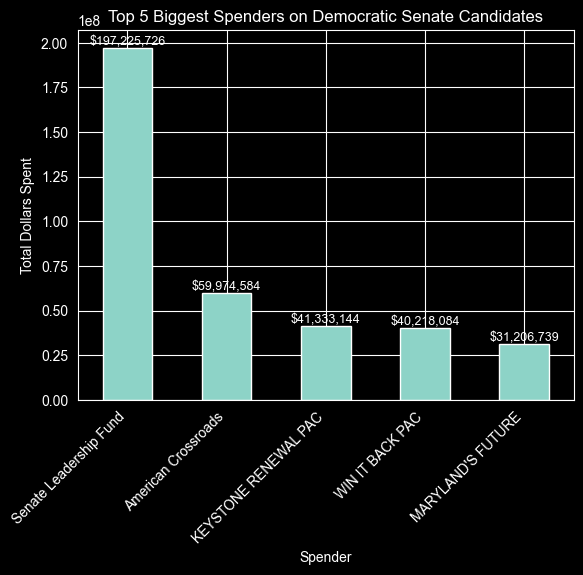

Top 5 Spenders for Republican Candidates:
                                               spe_nam       exp_amo
409                                          WinSenate  2.908055e+08
272                               DEFEND AMERICAN JOBS  5.115485e+07
246  Americans for Prosperity Action, Inc. (AFP Act...  4.828077e+07
281                                               DSCC  4.375485e+07
320                                Last Best Place PAC  3.202758e+07



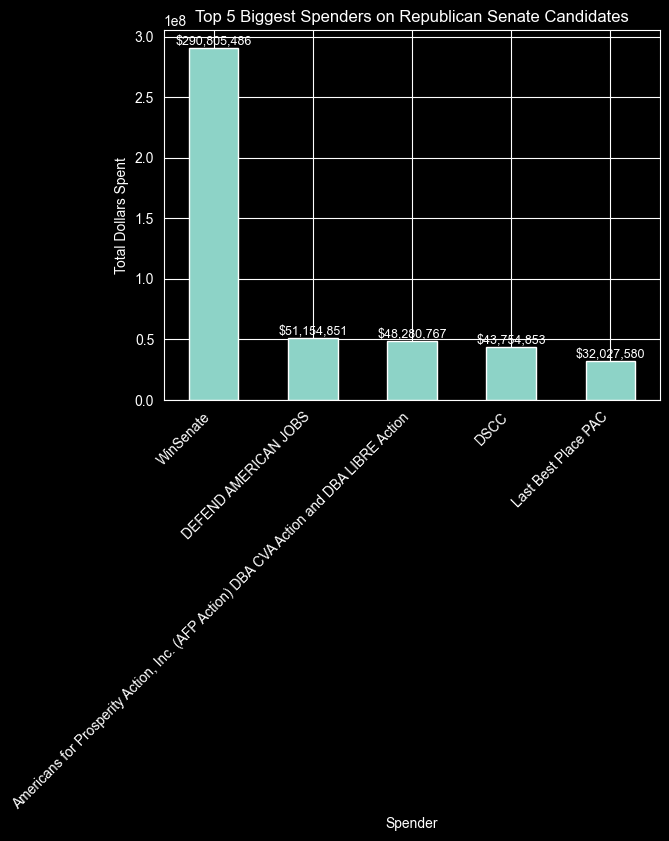

In [20]:
# just keep democratic and republican candidates
dem_rep_df = expendituresDataFrame[expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])].copy()

# group by PAC name and party
spender_totals = dem_rep_df.groupby(["cand_pty_aff", "spe_nam"])["exp_amo"].sum().reset_index()

# top 5 spenders for democrats
top5_dem = spender_totals[spender_totals["cand_pty_aff"] == "DEMOCRATIC PARTY"] \
    .sort_values("exp_amo", ascending=False) \
    .head(5)
print("Top 5 Spenders for Democratic Candidates:")
print(top5_dem[["spe_nam", "exp_amo"]])
print()
# democrat spender graph
ax = top5_dem.plot(kind="bar", x="spe_nam", y="exp_amo", legend=False)

plt.title("Top 5 Biggest Spenders on Democratic Senate Candidates")
plt.xlabel("Spender")
plt.ylabel("Total Dollars Spent")
plt.xticks(rotation=45, ha="right")
# total spending labels above bars
for i, value in enumerate(top5_dem["exp_amo"]):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

# top 5 spenders for republicans
top5_rep = spender_totals[spender_totals["cand_pty_aff"] == "REPUBLICAN PARTY"] \
    .sort_values("exp_amo", ascending=False) \
    .head(5)

print("Top 5 Spenders for Republican Candidates:")
print(top5_rep[["spe_nam", "exp_amo"]])
print()
# republican spender graph
ax = top5_rep.plot(kind="bar", x="spe_nam", y="exp_amo", legend=False)

plt.title("Top 5 Biggest Spenders on Republican Senate Candidates")
plt.xlabel("Spender")
plt.ylabel("Total Dollars Spent")
plt.xticks(rotation=45, ha="right")
# total spending labels above bars
for i, value in enumerate(top5_rep["exp_amo"]):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

Here we can see the 5 biggest Super PACs spenders for Democrats and Republicans. The Senate leadership fund has the greatest spending at 197,225,726 USD American Crossroads, Keystone Renewal, Win it Back, and Maryland's Future PACs all are then relatively close between 31,206,739 USD and 59,974,584 USD. The republican top 5 spenders shows a similar trend with WinSenate at 290,805,486 USD while the remaining four PACs range between 32,027,580 USD and 51,154,851 USD. This shows that there is one Super PAC that dominates spending for both Republicans and Democrats. The other spenders

#### Are supporting or opposing expenditures bigger?

Total Spending:
is_support
False    1.012636e+09
True     4.042900e+08
Name: exp_amo, dtype: float64



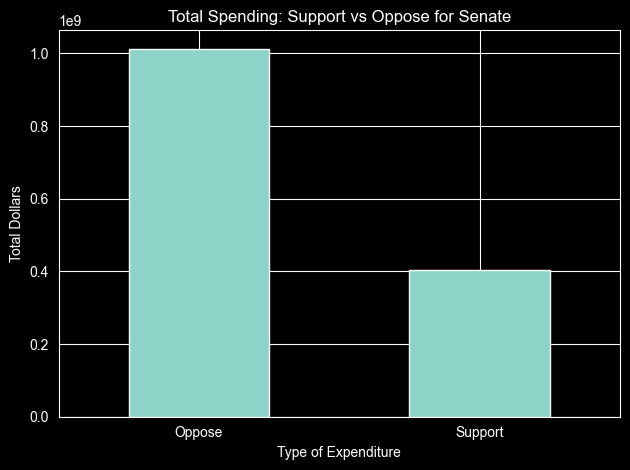

In [22]:
total_spending = expendituresDataFrame.groupby("is_support")["exp_amo"].sum()
print("Total Spending:")
print(total_spending)
print()
# total spending graph
total_spending.index = ["Oppose", "Support"]
total_spending.plot(kind="bar")
plt.title("Total Spending: Support vs Oppose for Senate")
plt.xlabel("Type of Expenditure")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The total dollars of Super PACs spending is over double for opposing expenditures compared to supporting.

#### Are supporting or opposing expenditures more common?

Number of Expenditures:
is_support
True     12889
False     4128
Name: count, dtype: int64



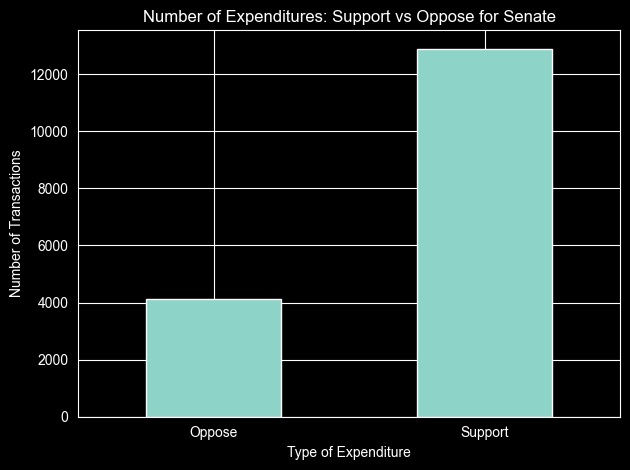

In [24]:
count_spending = expendituresDataFrame["is_support"].value_counts()

print("Number of Expenditures:")
print(count_spending)
print()
# Number of expenditures graph
count_spending = count_spending.sort_index()
count_spending.index = ["Oppose", "Support"]
count_spending.plot(kind="bar")
plt.title("Number of Expenditures: Support vs Oppose for Senate")
plt.xlabel("Type of Expenditure")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

While opposing expenditures by the dollar are over double compared to supporting, supporting is much more common than opposing expenditures have 8,761 more expenditures

#### How does spending lean politically?

Spending by Party and Support/Oppose:
cand_pty_aff_simpl  is_support
D                   False         5.492033e+08
                    True          1.497258e+08
O                   False         1.402833e+07
                    True          3.733824e+07
R                   False         4.494045e+08
                    True          2.172260e+08
Name: exp_amo, dtype: float64



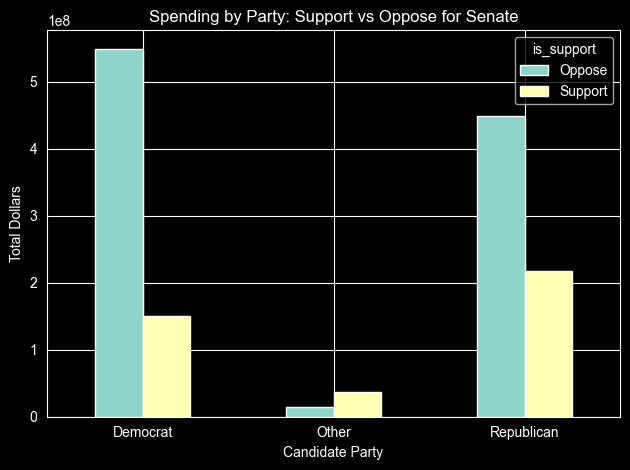

In [26]:
party_spending = expendituresDataFrame.groupby(["cand_pty_aff_simpl", "is_support"])["exp_amo"].sum()

print("Spending by Party and Support/Oppose:")
print(party_spending)
print()

# Convert to table format and rename columns
plot_df = party_spending.unstack().rename(columns={False: "Oppose", True: "Support"})

# Rename index labels (this is what changes the tick labels)
plot_df = plot_df.rename(index={"D": "Democrat", "R": "Republican", "O": "Other"})

# spending by party graph
plot_df.plot(kind="bar")
plt.title("Spending by Party: Support vs Oppose for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

While democrats and Republicans both follow the same trend of spending more on dollars, democrats oppose slightly more than they support compared to Republicans. Unlike Democrats and Republicans, other parties spend more supporting rather than opposing.

#### How does the number of expenditures lean politically?

Number of Expenditures by Party and Support/Oppose:
cand_pty_aff_simpl  is_support
D                   False         2171
                    True          7247
O                   False          229
                    True          1070
R                   False         1728
                    True          4572
dtype: int64



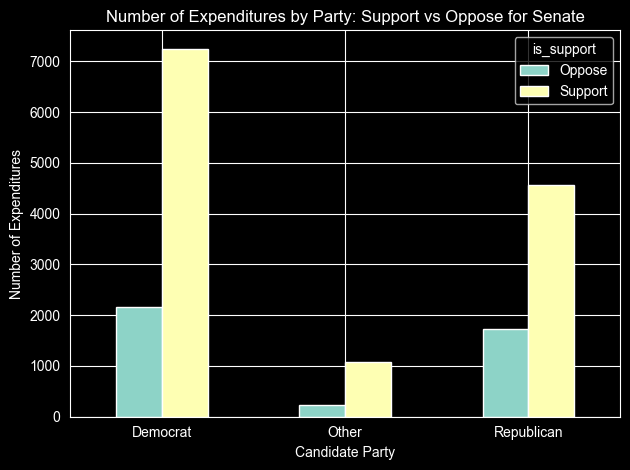

In [28]:
party_spending = expendituresDataFrame.groupby(["cand_pty_aff_simpl", "is_support"]).size()

print("Number of Expenditures by Party and Support/Oppose:")
print(party_spending)
print()

# Convert to table format and rename columns
plot_df = party_spending.unstack().rename(columns={False: "Oppose", True: "Support"})

# Rename index labels
plot_df = plot_df.rename(index={"D": "Democrat", "R": "Republican", "O": "Other"})

# spending by party graph
plot_df.plot(kind="bar")
plt.title("Number of Expenditures by Party: Support vs Oppose for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Number of Expenditures")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

While democrats generally spend more opposing than supporting, they more frequently make expenditures supporting compared to republicans. Both more frequently spend on supporting rather than opposing.

#### Net spending on parties

Democrat vs Republican Support/Oppose Spending:
is_support              Oppose       Support  Net Spending
cand_pty_aff                                              
DEMOCRATIC PARTY  5.492033e+08  1.497258e+08 -3.994775e+08
REPUBLICAN PARTY  4.494045e+08  2.172260e+08 -2.321785e+08



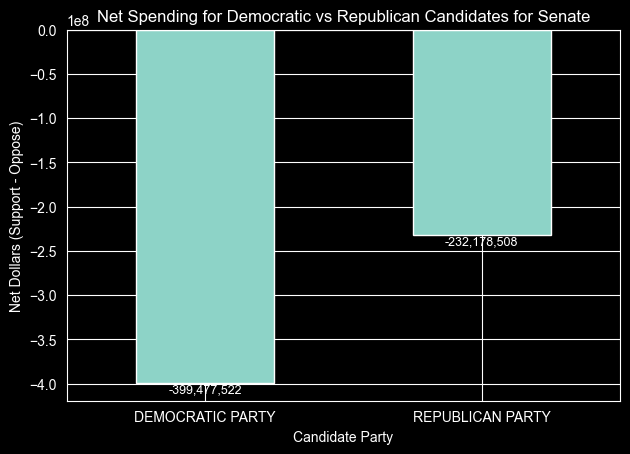

In [30]:
# net spending = support - oppose
# group support and oppose spending
dem_rep_support_opp = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].sum().unstack(fill_value=0)
# rename columns to look better
dem_rep_support_opp = dem_rep_support_opp.rename(columns={False: "Oppose", True: "Support"})
# net spending
dem_rep_support_opp["Net Spending"] = dem_rep_support_opp["Support"] - dem_rep_support_opp["Oppose"]

print("Democrat vs Republican Support/Oppose Spending:")
print(dem_rep_support_opp)
print()
# net spending graph
ax = dem_rep_support_opp["Net Spending"].plot(kind="bar")
plt.title("Net Spending for Democratic vs Republican Candidates for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Net Dollars (Support - Oppose)")
plt.xticks(rotation=0)
plt.axhline(0)
# net spending labels
for i, value in enumerate(dem_rep_support_opp["Net Spending"]):
    if value >= 0:
        ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)
    else:
        ax.text(i, value, f"{value:,.0f}", ha="center", va="top", fontsize=9)

plt.tight_layout()
plt.show()

Counting other parties opposing expenditures as a negative contribution and their supporting as a positive contribution we can see the net money contributed for or against each party. This goes to show that Democrats running for Senate are opposed more by the dollar than Republicans.

#### Does the size of a donation correlate with Republican or Democrat?
We are still working on this.

#### What effect do these donations have on the current Senate?

In [32]:
# to do:
# add a column to current_senators_df with total amount of PAC money received for, total amount of PAC money received against, number of pac donations for/against, average amount of money per pac donation, using data from main dataframe

# whoever was in charge of names, we still need to account for capitalization differences.

# for senator in current_senator_names:
#     if
#     senator_mask = expendituresDataFrame["cand_name"] == senator



# MUST DOUBLE CHECK THAT ALL NAMES APPEAR ONLY ONCE
# questions for this section (scope only for the current senators):
# is there a relationship between PAC donations and gender of the candidate?
# relationship between parties in current senate and pacs
# how is this relationship different from parties overall
# are the average/median/etc of amounts of money/donations different for current members
# (careful with correlation vs causation)
# remember to account for current senators who received no pac donations (and therefore won't be on the main dataframe)


# senator_mask = expendituresDataFrame["cand_name"].groupby("cand_name")
pd.set_option("display.max_columns", None)
test_senator_mask = expendituresDataFrame["cand_name_clean"] == ("ALSOBROOKS ANGELA")
expendituresDataFrame[test_senator_mask].head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,exp_date,agg_amo,sup_opp,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt,cand_pty_aff_simpl,cand_name_clean,is_support
0,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,29-OCT-24,1539.08,S,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN,D,ALSOBROOKS ANGELA,True
1,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,15102.50,02-NOV-24,16667.58,S,Event Coordination (Estimate),DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN,D,ALSOBROOKS ANGELA,True
3,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,DEMOCRATIC PARTY,75000.00,NaN,75000.00,S,Radio and Digital Ad Buy and Production (Estim...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24,D,ALSOBROOKS ANGELA,True
16,NaN,"Alsobrooks, Angela",C90016023,32BJ UNITED AMERICAN DREAM FUND,G,MD,0.0,S,NaN,11843.10,23-OCT-24,0.00,S,Canvass Labor (estimated),SEIU Local 32BJ,1841685,N,F57.000006,202410249713518190,24-OCT-24,2024,NaN,NaN,O,ALSOBROOKS ANGELA,True
17,NaN,"Alsobrooks, Angela",C90016023,32BJ UNITED AMERICAN DREAM FUND,G,MD,0.0,S,NaN,30334.00,21-OCT-24,0.00,S,Digital ad design production and distribution,Flores Consulting LLC,1836012,N,F57.000008,202410229710102342,22-OCT-24,2024,NaN,NaN,O,ALSOBROOKS ANGELA,True


#### How do swing states differ than non swing states?

Total spending by state:
   state  total_spending state_group
32    OH    3.141112e+08  Republican
34    PA    2.437889e+08       Swing
22    MT    1.702232e+08  Republican
18    MI    1.456032e+08       Swing
42    WI    1.240836e+08       Swing
30    NV    1.062022e+08       Swing
2     AZ    8.064944e+07       Swing
38    TX    6.076690e+07  Republican
16    MD    5.675728e+07  Democratic
26    NE    3.129331e+07  Republican
3     CA    2.499922e+07  Democratic
39    UT    1.685594e+07  Republican
7     FL    1.106355e+07  Republican
43    WV    8.088527e+06  Republican
20    MO    4.456665e+06  Republican
12    IN    4.218781e+06  Republican
29    NM    4.075653e+06  Democratic
15    MA    2.111275e+06  Democratic
28    NJ    1.899095e+06  Democratic
37    TN    1.163468e+06  Republican
44    WY    1.007628e+06  Republican
40    VA    6.884924e+05  Democratic
8     GA    5.988017e+05       Swing
21    MS    4.700500e+05  Republican
35    RI    3.485373e+05  Democratic
33    OK    2

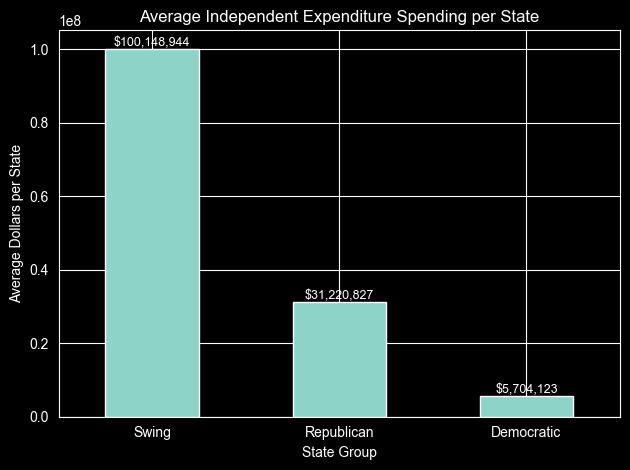

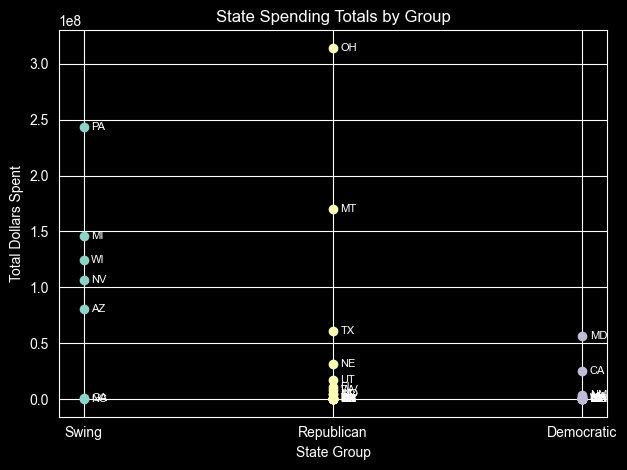

In [33]:
# total spending by state
state_totals = expendituresDataFrame.groupby("can_office_state")["exp_amo"].sum().reset_index()
state_totals.columns = ["state", "total_spending"]

# classify state into republican, democrat, or swing
def classify_state(state):
    if state in swing_states:
        return "Swing"
    elif state in republican_states:
        return "Republican"
    elif state in democratic_states:
        return "Democratic"
    else:
        return "Other"
state_totals["state_group"] = state_totals["state"].apply(classify_state)


print("Total spending by state:")
print(state_totals.sort_values("total_spending", ascending=False))
print()

# average spending per state for each group
group_avg = state_totals.groupby("state_group")["total_spending"].mean().reindex(["Swing", "Republican", "Democratic"])

print("Average spending per state by group:")
print(group_avg)
print()

# total spending and number of states in each group
group_summary = state_totals.groupby("state_group").agg(average_spending=("total_spending", "mean"),total_spending=("total_spending", "sum"),number_of_states=("state", "count")).reindex(["Swing", "Republican", "Democratic"])

print("Summary by group:")
print(group_summary)
print()

# Average spending per state bar graph
ax = group_avg.plot(kind="bar")
plt.title("Average Independent Expenditure Spending per State")
plt.xlabel("State Group")
plt.ylabel("Average Dollars per State")
plt.xticks(rotation=0)
for i, value in enumerate(group_avg):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Individual state totals dot graph
# driven by only a few states
group_order = ["Swing", "Republican", "Democratic"]
x_positions = {group: i for i, group in enumerate(group_order)}

for group in group_order:
    group_data = state_totals[state_totals["state_group"] == group]
    x_vals = [x_positions[group]] * len(group_data)
    plt.scatter(x_vals, group_data["total_spending"])

    # label each point with the state abbreviation
    for _, row in group_data.iterrows():
        plt.text( x_positions[group] + 0.03, row["total_spending"], row["state"], fontsize=8, va="center")

plt.xticks([0, 1, 2], group_order)
plt.title("State Spending Totals by Group")
plt.xlabel("State Group")
plt.ylabel("Total Dollars Spent")
plt.tight_layout()
plt.show()

Our first graph here shows that states classified as swing states have a higher average independent expenditure spending than republican states by over double. Democratic states are nearly a half of the republican states. Swing states generally spend more than established Republican or Democratic states

#### When are Expenditures Made?

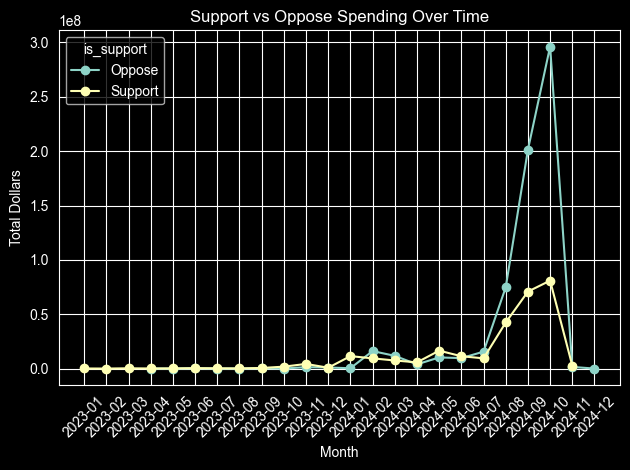

In [35]:
# Convert exp_date to datetime
expendituresDataFrame["exp_date"] = pd.to_datetime(expendituresDataFrame["exp_date"], format="%d-%b-%y", errors="coerce")

date_df = expendituresDataFrame.dropna(subset=["exp_date"]).copy()
date_df["year_month"] = date_df["exp_date"].dt.to_period("M")
monthly_spending = date_df.groupby("year_month")["exp_amo"].sum()

monthly_support = date_df.groupby(["year_month", "is_support"])["exp_amo"].sum().unstack()
monthly_support.index = monthly_support.index.astype(str)
monthly_support.rename(columns={True: "Support", False: "Oppose"}).plot(kind="line", marker="o")

plt.title("Support vs Oppose Spending Over Time")
plt.xlabel("Month")
plt.ylabel("Total Dollars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.xticks(range(len(monthly_support.index)), monthly_support.index, rotation=45)
plt.show()

Serious spending for both supporting and opposing typically began on June 2024 for the elections in November. We expected to see spiked spending shortly before the elections.

#### Top 5 Spending Purposes

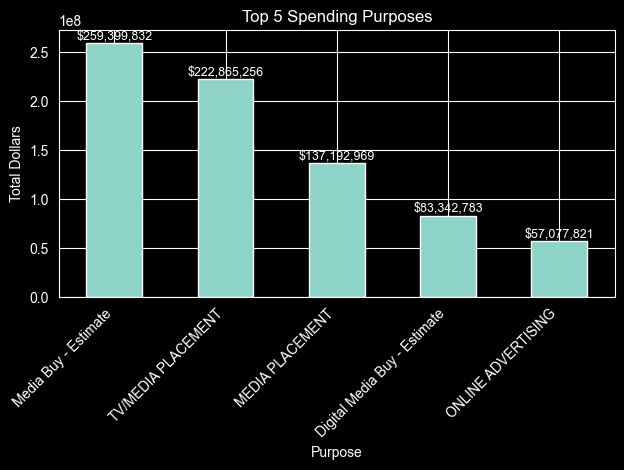

In [37]:
purpose_spending = expendituresDataFrame.groupby("pur")["exp_amo"].sum()

# Get top 5 purposes
top5_purposes = purpose_spending.sort_values(ascending=False).head(5)

# Plot bar graph
ax = top5_purposes.plot(kind="bar")

plt.title("Top 5 Spending Purposes")
plt.xlabel("Purpose")
plt.ylabel("Total Dollars")
plt.xticks(rotation=45, ha="right")

# Add dollar labels above bars
for i, value in enumerate(top5_purposes):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

The top 5 spending purposes are all media, TV, and digital related.

#### Top 5 Keywords for Spending

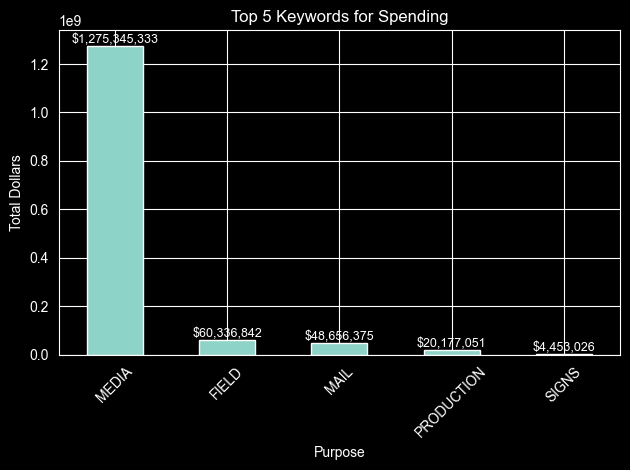

In [39]:
# Apply cleaning
expendituresDataFrame["pur_clean"] = expendituresDataFrame["pur"].apply(clean_purpose)

# Group by cleaned purpose and sum spending
purpose_spending = expendituresDataFrame.groupby("pur_clean")["exp_amo"].sum()

# Get top 5 cleaned purposes
top5_purposes = purpose_spending.sort_values(ascending=False).head(5)

# Plot
ax = top5_purposes.plot(kind="bar")

plt.title("Top 5 Keywords for Spending")
plt.xlabel("Purpose")
plt.ylabel("Total Dollars")
plt.xticks(rotation=45)

# Add dollar labels above bars
for i, value in enumerate(top5_purposes):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Media spending dominates all other keyword spending purposes. Field related, mail production and then signs then follow.


#### Mean size of donations support/ opposing for democrats and republicans

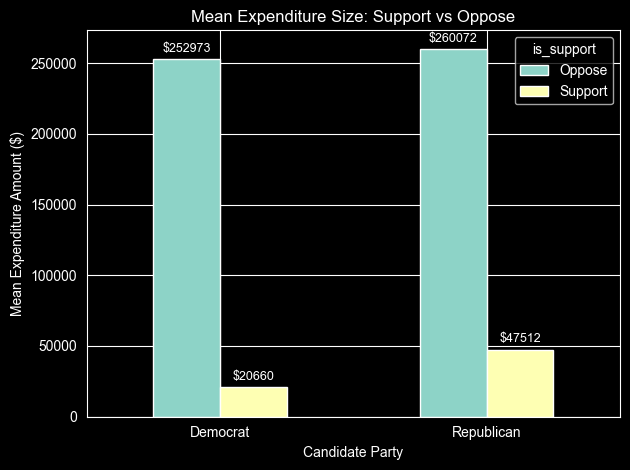

In [41]:
# Group by candidate party and support/oppose, then take mean donation size
mean_spending = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].mean()

# Convert to table format
plot_df = mean_spending.unstack().rename(columns={False: "Oppose", True: "Support"})

# Rename row
plot_df = plot_df.rename(index={"DEMOCRATIC PARTY": "Democrat", "REPUBLICAN PARTY": "Republican"})

# Plot grouped bar chart
ax = plot_df.plot(kind="bar")

plt.title("Mean Expenditure Size: Support vs Oppose")
plt.xlabel("Candidate Party")
plt.ylabel("Mean Expenditure Amount ($)")
plt.xticks(rotation=0)

# dollar labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

#### Median Size of Donations Supporting/ Opposing for Democrats and Republicans

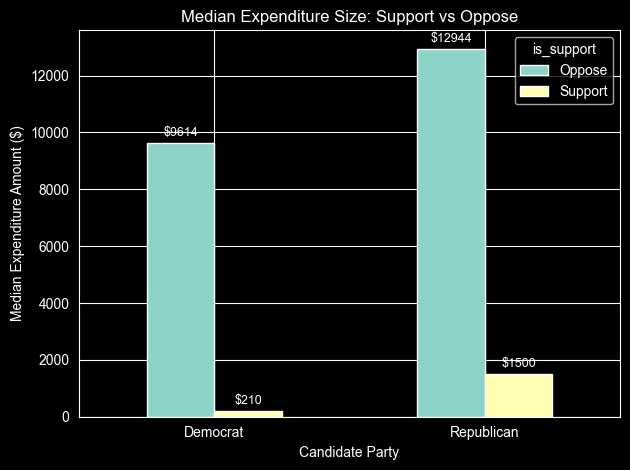

In [42]:
# median
median_spending = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].median()

# Convert to table format
plot_df = median_spending.unstack().rename(columns={False: "Oppose", True: "Support"})

# Rename row labels
plot_df = plot_df.rename(index={"DEMOCRATIC PARTY": "Democrat", "REPUBLICAN PARTY": "Republican"})

# Plot grouped bar chart
ax = plot_df.plot(kind="bar")

plt.title("Median Expenditure Size: Support vs Oppose")
plt.xlabel("Candidate Party")
plt.ylabel("Median Expenditure Amount ($)")
plt.xticks(rotation=0)

# Add dollar labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

#### Where do donations differ?

In [43]:
print("The number of Republican SUPER PACs expenditures from 2022-24 is " + str(republicanExpendituresDataFrame.size))
print("The number of Democrat SUPER PACs expenditures from 2022-24 is " + str(democratExpendituresDataFrame.size))

print("The number of large Republican SUPER PACs expenditures (>$1,000,000) from 2022-24 is " + str(largeRepublicanExpendituresDataFrame.size))
print("The number of large Democrat SUPER PACs expenditures (>$1,000,000) from 2022-24 is " + str(largeDemocratExpendituresDataFrame.size))


totalRepublicanExpenditures = republicanExpendituresDataFrame['exp_amo'].sum()
totalDemocratExpenditures = democratExpendituresDataFrame['exp_amo'].sum()

totalLargeRepublicanExpenditures = largeRepublicanExpendituresDataFrame['exp_amo'].sum()
totalLargeDemocratExpenditures = largeDemocratExpendituresDataFrame['exp_amo'].sum()


print(f"The sum of all large republican expenditures was {totalLargeRepublicanExpenditures}")
print(f"The sum of all large democrat expenditures was {totalLargeDemocratExpenditures}")



The number of Republican SUPER PACs expenditures from 2022-24 is 163800
The number of Democrat SUPER PACs expenditures from 2022-24 is 244868
The number of large Republican SUPER PACs expenditures (>$1,000,000) from 2022-24 is 4524
The number of large Democrat SUPER PACs expenditures (>$1,000,000) from 2022-24 is 4862
The sum of all large republican expenditures was 384850326.15
The sum of all large democrat expenditures was 441851678.11


#### Which states have the most money going to them?

In [44]:
# prepare data
state_df = expendituresDataFrame.dropna(subset=["can_office_state"]).copy()
state_df["exp_amo"] = pd.to_numeric(state_df["exp_amo"], errors="coerce")

# group by state
state_spending = state_df.groupby("can_office_state")["exp_amo"].sum().reset_index()
state_spending.columns = ["state", "total_spending"]

# create map
fig = px.choropleth(state_spending, locations="state", locationmode="USA-states", color="total_spending", scope="usa", color_continuous_scale="Reds", title="Total Super PAC Spending by State (Senate)", labels={"total_spending": "Total Spending"})

# save and display
fig.write_html("map.html")

IFrame("map.html", width=900, height=600)

Major states with prospective Senators recieving money are OH, PA, MT, MI, and WI - typically swing states had more money spent. States that are black have no data about them.

### PAC Donations and the Current Senate

In [46]:
# to do:
# add a column to current_senators_df with total amount of PAC money received for, total amount of PAC money received against, number of pac donations for/against, average amount of money per pac donation, using data from main dataframe

# whoever was in charge of names, we still need to account for capitalization differences.

# for senator in current_senator_names:
#     if
#     senator_mask = expendituresDataFrame["cand_name"] == senator



# MUST DOUBLE CHECK THAT ALL NAMES APPEAR ONLY ONCE
# questions for this section (scope only for the current senators):
# is there a relationship between PAC donations and gender of the candidate?
# relationship between parties in current senate and pacs
# how is this relationship different from parties overall
# are the average/median/etc of amounts of money/donations different for current members
# (careful with correlation vs causation)
# remember to account for current senators who received no pac donations (and therefore won't be on the main dataframe)

current_senators_df.head()

,state,party,gender,supporting donations received,opposing donations received,sum of supporting donations,sum of opposing donations,net donations,mean supporting donation size,mean opposing donation size,median supporting donation size,median opposing donation size
name,,,,,,,,,,,,
TUBERVILLE THOMAS,AL,R,M,10,2,14214.84,10000.0,4214.84,1421.484000,5000.0,43.475,5000.0
BRITT KATIE,AL,R,F,0,0,0.00,0.0,0.00,0.000000,0.0,0.000,0.0
MURKOWSKI LISA,AK,R,F,0,0,0.00,0.0,0.00,0.000000,0.0,0.000,0.0
SULLIVAN DAN,AK,R,M,0,0,0.00,0.0,0.00,0.000000,0.0,0.000,0.0
KELLY MARK,AZ,D,M,3,0,11201.62,0.0,11201.62,3733.873333,0.0,500.000,0.0


#### How do these expenditures look visually?

In [47]:

from IPython.display import IFrame
IFrame(src="https://magicdracon.github.io", width="100%", height=400)

#### Quantity vs Quality of donations

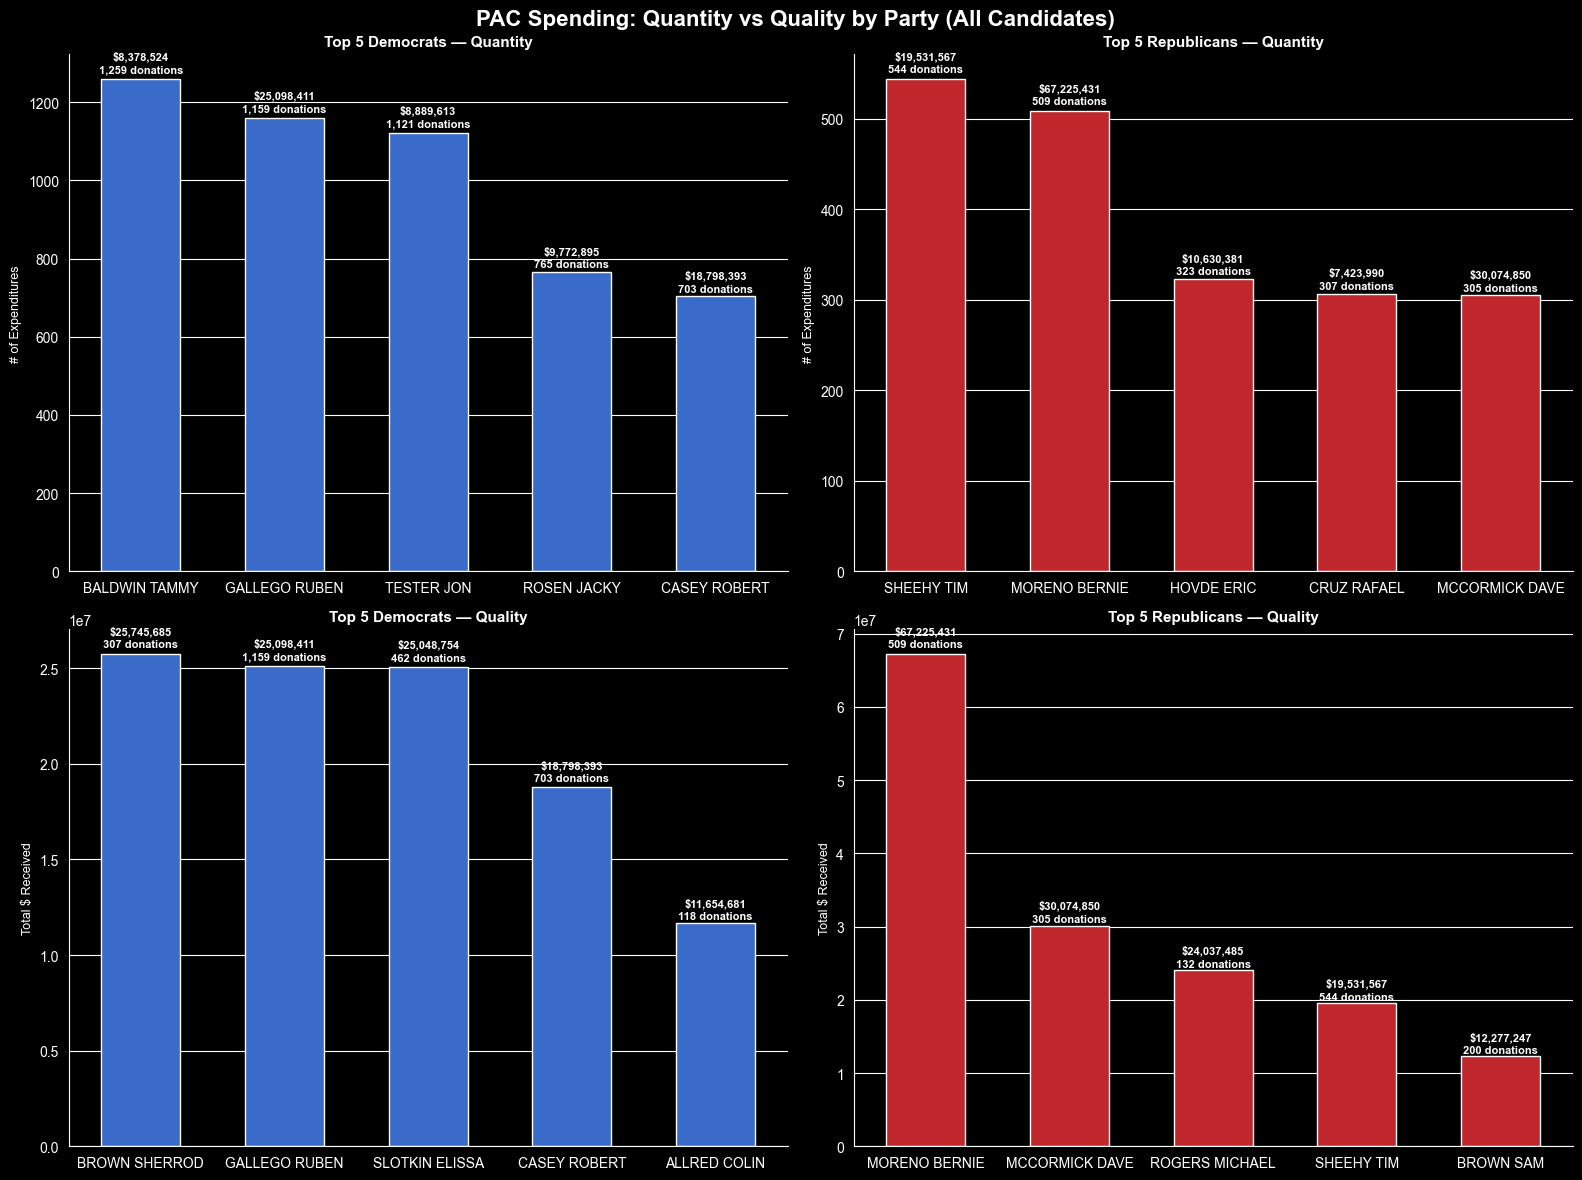

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("PAC Spending: Quantity vs Quality by Party (All Candidates)", fontsize=16, fontweight="bold")

sup_df = expendituresDataFrame[expendituresDataFrame["sup_opp"] == "S"]

dem_sup = sup_df[sup_df["cand_pty_aff_simpl"] == "D"]
rep_sup = sup_df[sup_df["cand_pty_aff_simpl"] == "R"]

top5_dem_count = dem_sup.groupby("cand_name_clean")["exp_amo"].count().sort_values(ascending=False).head(5)
top5_rep_count = rep_sup.groupby("cand_name_clean")["exp_amo"].count().sort_values(ascending=False).head(5)
top5_dem_sum   = dem_sup.groupby("cand_name_clean")["exp_amo"].sum().sort_values(ascending=False).head(5)
top5_rep_sum   = rep_sup.groupby("cand_name_clean")["exp_amo"].sum().sort_values(ascending=False).head(5)

dem_sum_lookup   = dem_sup.groupby("cand_name_clean")["exp_amo"].sum()
rep_sum_lookup   = rep_sup.groupby("cand_name_clean")["exp_amo"].sum()
dem_count_lookup = dem_sup.groupby("cand_name_clean")["exp_amo"].count()
rep_count_lookup = rep_sup.groupby("cand_name_clean")["exp_amo"].count()

for ax, data, sum_lookup, count_lookup, color, title, ylabel in [
    (axes[0,0], top5_dem_count, dem_sum_lookup, dem_count_lookup, "#3a6bc9", "Top 5 Democrats — Quantity",  "# of Expenditures"),
    (axes[0,1], top5_rep_count, rep_sum_lookup, rep_count_lookup, "#c0272d", "Top 5 Republicans — Quantity","# of Expenditures"),
    (axes[1,0], top5_dem_sum,   dem_sum_lookup, dem_count_lookup, "#3a6bc9", "Top 5 Democrats — Quality",   "Total $ Received"),
    (axes[1,1], top5_rep_sum,   rep_sum_lookup, rep_count_lookup, "#c0272d", "Top 5 Republicans — Quality", "Total $ Received"),
]:
    bars = ax.bar(data.index, data.values, color=color, edgecolor="white", width=0.55)
    for bar, cand in zip(bars, data.index):
        count_val = count_lookup.get(cand, 0)
        sum_val   = sum_lookup.get(cand, 0)
        combined  = f"${sum_val:,.0f}\n{count_val:,} donations"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                combined, ha="center", va="bottom", fontsize=8, fontweight="bold", linespacing=1.4)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

### What did PAC donations look like for the current (as of 2026) members of the Senate from 2022-2024?

Up to this point, most of what we have been able to do with our data has been a somewhat broad, so we were interested to see how this data translated to the current members of the Senate (all of whom had their most recent election in either 2022 or 2026).  It is important to note that, for the current senate members, we continued to use only the PAC donations for senate seats between 2022 and 2024.  This means that it is very likely that these are not the only PAC donations that these senators have received, either because they have previously run, or because they also made a bid for another office - for example, South Carolina senator Timothy Scott also ran in the 2024 presidential race.

We also want to note that, although it is tempting to do so when bringing in the people who actually won these offices, we do not have sufficient data to conclude if and how PAC donations influence election outcomes.  We intend only to examine correlation, not to imply causation.

#### Analyzing Number of and Total Amount Received from PAC Donations to Current Senate Members

In [49]:
# graph - how much total money went into supporting/opposing current senate members?
democratic_current_senators_df = (current_senators_df[current_senators_df["party"] == "D"])
republican_current_senators_df = (current_senators_df[current_senators_df["party"] == "R"])
other_current_senators_df = (current_senators_df[current_senators_df["party"] == "O"])

print("supporting rep")
total_amount_supporting_rep = republican_current_senators_df["sum of supporting donations"].sum()
print(total_amount_supporting_rep)
print("opposing rep")
total_amount_opposing_rep = republican_current_senators_df["sum of opposing donations"].sum()
print(total_amount_opposing_rep)

print("supporting dem")
total_amount_supporting_dem = democratic_current_senators_df["sum of supporting donations"].sum()
print(total_amount_supporting_dem)
print("opposing dem")
total_amount_opposing_dem = democratic_current_senators_df["sum of opposing donations"].sum()
print(total_amount_opposing_dem)

print("supporting other")
total_amount_supporting_other = democratic_current_senators_df["sum of supporting donations"].sum()
print(total_amount_supporting_other)
print("opposing other")
total_amount_opposing_other = other_current_senators_df["sum of opposing donations"].sum()
print(total_amount_opposing_other)

print(len(republican_current_senators_df))


# democratic_current_senators_df.head()
republican_current_senators_df.head()
# other_current_senators_df.head()

supporting rep
145006247.74
opposing rep
243913015.45999998
supporting dem
77875895.1
opposing dem
191873830.88000003
supporting other
77875895.1
opposing other
0.0
53


,state,party,gender,supporting donations received,opposing donations received,sum of supporting donations,sum of opposing donations,net donations,mean supporting donation size,mean opposing donation size,median supporting donation size,median opposing donation size
name,,,,,,,,,,,,
TUBERVILLE THOMAS,AL,R,M,10,2,14214.84,10000.0,4214.84,1421.484,5000.0,43.475,5000.0
BRITT KATIE,AL,R,F,0,0,0.00,0.0,0.00,0.000,0.0,0.000,0.0
MURKOWSKI LISA,AK,R,F,0,0,0.00,0.0,0.00,0.000,0.0,0.000,0.0
SULLIVAN DAN,AK,R,M,0,0,0.00,0.0,0.00,0.000,0.0,0.000,0.0
BOOZMAN JOHN,AR,R,M,0,0,0.00,0.0,0.00,0.000,0.0,0.000,0.0


There are only two non-democrat and non-republican senators currently in the senate (Angus King and Bernie Sanders), only one of whom received any PAC donations.  Because both of these Independent senators caucus with the democrats (https://www.congress.gov/crs-product/R48535), from this point forward, they will be included in the "democrat" category.

In [50]:
democratic_current_senators_df = (current_senators_df[current_senators_df["party"] != "R"])
print("supporting dem")
total_amount_supporting_dem = democratic_current_senators_df["sum of supporting donations"].sum()
print(total_amount_supporting_dem)
print("opposing dem")
total_amount_opposing_dem = democratic_current_senators_df["sum of opposing donations"].sum()
print(total_amount_opposing_dem)

supporting dem
77908615.1
opposing dem
191873830.88


First, we used a bar graph to compare the total amount of PAC money donated to Republican and Democrat (or Democrat-aligned) Senators:

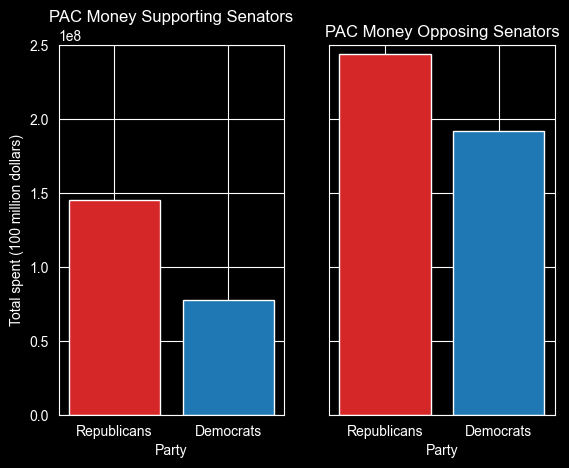

In [101]:
# bar graph for amount of supporting donated
fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].bar(["Republicans", "Democrats"], [total_amount_supporting_rep, total_amount_supporting_dem], color=['tab:red', 'tab:blue'])
axs[0].set_title("PAC Money Supporting Senators")
axs[0].set_xlabel("Party")
axs[0].set_ylabel("Total spent (100 million dollars)")
axs[0].set_ylim(0,250000000)
axs[1].bar(["Republicans", "Democrats"], [total_amount_opposing_rep, total_amount_opposing_dem], color=['tab:red', 'tab:blue'])
axs[1].set_title("PAC Money Opposing Senators")
axs[1].set_xlabel("Party")
axs[1].set_ylim(0,250000000)

plt.show()


Like in our main dataframe, we noticed that more money was spent on opposing candidates than on supporting them, with a bit more of a gap between supporting and opposing democratic senators.  However, in the main dataset, the gaps between supporting and opposing totals were much more extreme for both parties, and the total amount of PAC money opposing Democrats was higher than that for Republicans.

supporting rep
2975
opposing rep
977
supporting dem
4764
opposing dem
970


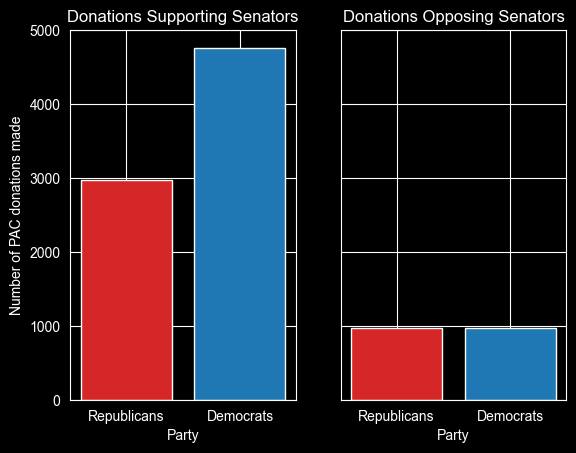

In [102]:
# bar graph for number of donations
print("supporting rep")
donations_supporting_rep = republican_current_senators_df["supporting donations received"].sum()
print(donations_supporting_rep)
print("opposing rep")
donations_opposing_rep = republican_current_senators_df["opposing donations received"].sum()
print(donations_opposing_rep)

print("supporting dem")
donations_supporting_dem = democratic_current_senators_df["supporting donations received"].sum()
print(donations_supporting_dem)
print("opposing dem")
donations_opposing_dem = democratic_current_senators_df["opposing donations received"].sum()
print(donations_opposing_dem)

fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].bar(["Republicans", "Democrats"], [donations_supporting_rep, donations_supporting_dem], color=['tab:red', 'tab:blue'])
axs[0].set_title("Donations Supporting Senators")
axs[0].set_xlabel("Party")
axs[0].set_ylabel("Number of PAC donations made")
axs[0].set_ylim(0,5000)

axs[1].bar(["Republicans", "Democrats"], [donations_opposing_rep, donations_opposing_dem], color=['tab:red', 'tab:blue'])
axs[1].set_title("Donations Opposing Senators")
axs[1].set_xlabel("Party")
axs[1].set_ylim(0,5000)

plt.show()

With another bar graph for the number of PAC donations made to current senators by party, we continue to see how patterns from the larger dataset extend to this smaller one.  Just like before, we see that democrats received more supporting donations than republicans, and that the number of opposing donations in each party was much closer.  We also noticed, again, that the number of donations does not necessarily "fit" the amount of money collected from donations, meaning that there is a large difference in the size of donations made in each of these categories.  So, next we will look at the mean donation amount for each party in the current senate, compared to overall.

In [158]:
# current_senators_df.head(0)
# expendituresDataFrame.head()

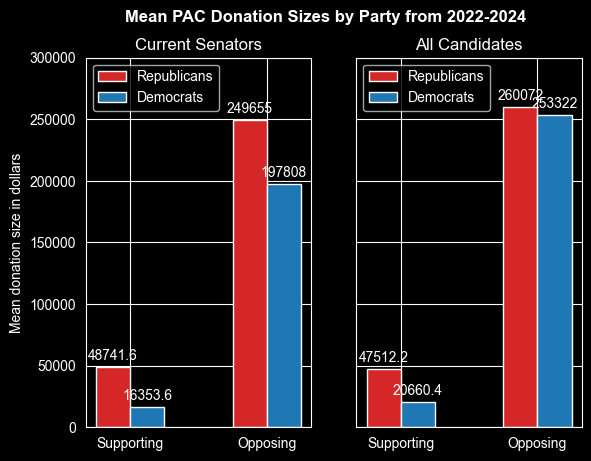

In [266]:
mean_size_supp_rep = total_amount_supporting_rep / donations_supporting_rep
mean_size_supp_dem = total_amount_supporting_dem / donations_supporting_dem
mean_size_opp_rep = total_amount_opposing_rep / donations_opposing_rep
mean_size_opp_dem = total_amount_opposing_dem / donations_opposing_dem


# print(mean_size_supp_rep)
# print(mean_size_supp_dem)
# print(mean_size_opp_rep)
# print(mean_size_opp_dem)
# print()

width = .25
multiplier = 0

supp_labels = ["Supporting", "Opposing"]

colors = ['tab:red', 'tab:blue']

senator_means = {"Republicans":(mean_size_supp_rep, mean_size_opp_rep), "Democrats":(mean_size_supp_dem, mean_size_opp_dem)}

x = np.arange(len(supp_labels))

fig, axs = plt.subplots(1, 2, sharey=True)

fig.suptitle("Mean PAC Donation Sizes by Party from 2022-2024", fontweight="bold")

for attribute, measurement in senator_means.items():
    color = colors[multiplier]
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, label=attribute, color=color)
    axs[0].bar_label(rects, padding=3)
    multiplier += 1

axs[0].set_ylabel('Mean donation size in dollars')
axs[0].set_title('Current Senators')
axs[0].set_xticks(x + width/2, supp_labels)
axs[0].legend(loc='upper left', ncols=1)
axs[0].set_ylim(0, 300000)

supp_mask = republicanExpendituresDataFrame["sup_opp"] == "S"
opp_mask = republicanExpendituresDataFrame["sup_opp"] == "O"
all_rep_supp_mean = republicanExpendituresDataFrame[supp_mask]["exp_amo"].sum() / len(republicanExpendituresDataFrame[supp_mask])
all_rep_opp_mean = republicanExpendituresDataFrame[opp_mask]["exp_amo"].sum() / len(republicanExpendituresDataFrame[opp_mask])
supp_mask = democratExpendituresDataFrame["sup_opp"] == "S"
opp_mask = democratExpendituresDataFrame["sup_opp"] == "O"
all_dem_supp_mean = democratExpendituresDataFrame[supp_mask]["exp_amo"].sum() / len(democratExpendituresDataFrame[supp_mask])
all_dem_opp_mean = democratExpendituresDataFrame[opp_mask]["exp_amo"].sum() / len(democratExpendituresDataFrame[opp_mask])

all_cand_means = {"Republicans":(all_rep_supp_mean, all_rep_opp_mean), "Democrats":(all_dem_supp_mean, all_dem_opp_mean)}

multiplier = 0

for attribute, measurement in all_cand_means.items():
    color = colors[multiplier]
    offset = width * multiplier
    rects = axs[1].bar(x + offset, measurement, width, label=attribute, color=color)
    axs[1].bar_label(rects, padding=3)
    multiplier += 1

# axs[1].set_ylabel('Mean donation size')
axs[1].set_title('All Candidates')
axs[1].set_xticks(x + width/2, supp_labels)
axs[1].legend(loc='upper left', ncols=1)
# axs[0].set_ylim(0, 30)



plt.show()
# print(republicanExpendituresDataFrame["exp_amo"].count())
# print(republicanExpendituresDataFrame[supp_mask]["exp_amo"].sum())
# print(len(republicanExpendituresDataFrame[opp_mask]))
# democratExpendituresDataFrame[opp_mask].head()

As we predicted by the difference in the sum of money graphs and the donation count graphs, there is a very large difference between donation sizes for supporting and opposing PACs.  We have already examined this (with medians as well as with means) above, but what we found particularly interesting about these numbers for the current senators is that, while the mean donation sizes are nearly the exact same for opposing and supporting for Republicans in either graph, there is a slightly larger difference in the mean donation size supporting senators (just over 4,000 dollars less for current senators), and a very large difference in opposing donations (about 55,500 dollars less for current senators).

#### 2026 Senate Makeup

To put this into perspective of how much of the senate is involved with PACs, we will use a pie chart.

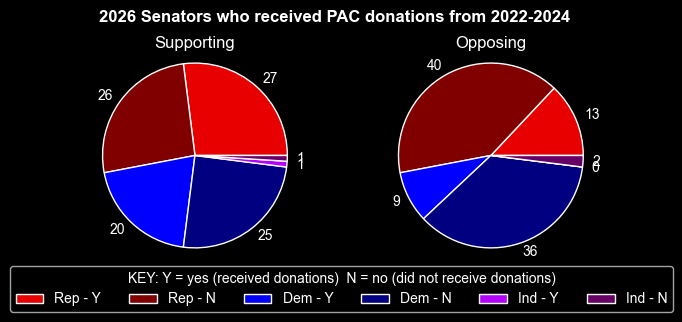

In [326]:
# pulling independent back out of democrat
democratic_current_senators_df = (current_senators_df[current_senators_df["party"] == "D"])
other_current_senators_df = (current_senators_df[current_senators_df["party"] == "O"])


rep_sup_current = republican_current_senators_df[republican_current_senators_df["supporting donations received"] > 0]
rep_sup_senator_count = len(rep_sup_current)
rep_no_sup_current = republican_current_senators_df[republican_current_senators_df["supporting donations received"] == 0]
rep_no_sup_senator_count = len(rep_no_sup_current)

dem_sup_current = democratic_current_senators_df[democratic_current_senators_df["supporting donations received"] > 0]
dem_sup_senator_count = len(dem_sup_current)
dem_no_sup_current = democratic_current_senators_df[democratic_current_senators_df["supporting donations received"] == 0]
dem_no_sup_senator_count = len(dem_no_sup_current)

rep_opp_current = republican_current_senators_df[republican_current_senators_df["opposing donations received"] > 0]
rep_opp_senator_count = len(rep_opp_current)
rep_no_opp_current = republican_current_senators_df[republican_current_senators_df["opposing donations received"] == 0]
rep_no_opp_senator_count = len(rep_no_opp_current)

dem_opp_current = democratic_current_senators_df[democratic_current_senators_df["opposing donations received"] > 0]
dem_opp_senator_count = len(dem_opp_current)
dem_no_opp_current = democratic_current_senators_df[democratic_current_senators_df["opposing donations received"] == 0]
dem_no_opp_senator_count = len(dem_no_opp_current)

ind_sup_current = other_current_senators_df[other_current_senators_df["supporting donations received"] > 0]
ind_sup_senator_count = len(ind_sup_current)
ind_no_sup_current = other_current_senators_df[other_current_senators_df["supporting donations received"] == 0]
ind_no_sup_senator_count = len(ind_no_sup_current)

ind_opp_current = other_current_senators_df[other_current_senators_df["opposing donations received"] > 0]
ind_opp_senator_count = len(ind_opp_current)
ind_no_opp_current = other_current_senators_df[other_current_senators_df["opposing donations received"] == 0]
ind_no_opp_senator_count = len(ind_no_opp_current)

colors = ((.91, 0, 0), (.5, 0, 0), (0, 0, 1), (0, 0, .5), (.7, 0, 1), (.4, 0, .4))
supp_counts = (rep_sup_senator_count, rep_no_sup_senator_count, dem_sup_senator_count, dem_no_sup_senator_count, ind_sup_senator_count, ind_no_sup_senator_count)
supp_labels = ("Rep - Y", "Rep - N", "Dem - Y", "Dem - N", "Ind - Y", "Ind - N")

opp_counts = (rep_opp_senator_count, rep_no_opp_senator_count, dem_opp_senator_count, dem_no_opp_senator_count, ind_opp_senator_count, ind_no_opp_senator_count)
opp_labels = ("Rep - Y", "Rep - N", "Dem - Y", "Dem - N", "Ind - Y", "Ind - N")


fig, axs = plt.subplots(1, 2, figsize=(7, 3), subplot_kw=dict(aspect="equal"))
fig.suptitle("2026 Senators who received PAC donations from 2022-2024", fontweight="bold")

axs[0].pie(supp_counts, labels=supp_counts, colors=colors)
axs[0].set_title("Supporting", y=0.93)

fig.legend(title='KEY: Y = yes (received donations)  N = no (did not receive donations)', labels=supp_labels, loc="center left", bbox_to_anchor=(0.027, -.2, 0, 0.5), ncols=6)

axs[1].pie(opp_counts, labels=opp_counts, colors=colors)
axs[1].set_title("Opposing", y=0.93)
# axs[1].legend(labels=opp_labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

In these pie charts, we can see the proportion of senators from each party who received PAC donations for or against them.  One thing we notice immediately is that a surprising number of senators did not receive any supporting PAC donations - in total, just over half (52%) had no PAC donations.  This is also true of opposing donations: 78% of the US Senate did not receive PAC donations against them.  Considering how large our dataset was (and especially how large many of the totals came out), we were expecting the majority of our senators to receive PACs in the last election, with few exceptions.  What this means, then, is that PAC donations tend to be very concentrated, with many large donations going to a small proportion of people -- an idea that is supported by the rest of our analysis.

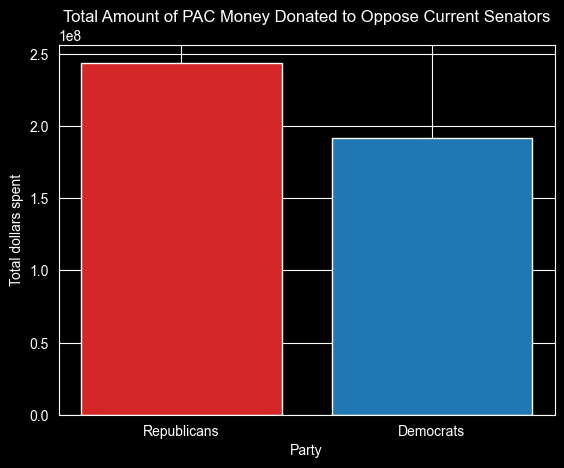

In [53]:
fig, ax = plt.subplots()
ax.bar(["Republicans", "Democrats"], [total_amount_opposing_rep, total_amount_opposing_dem], color=['tab:red', 'tab:blue'])
ax.set_title("Total Amount of PAC Money Donated to Oppose Current Senators")
ax.set_xlabel("Party")
ax.set_ylabel("Total dollars spent")
plt.show()

(0.0, 30.0)

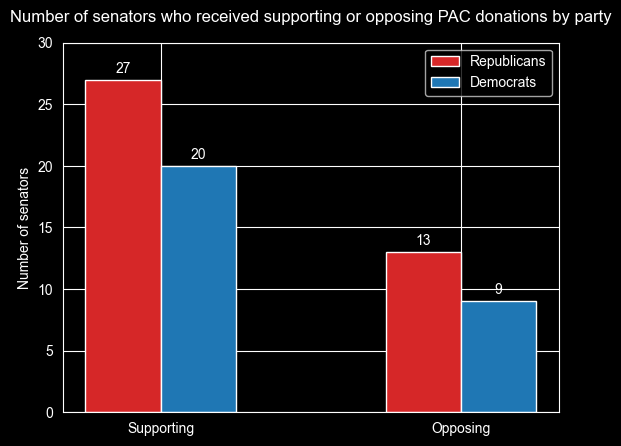

In [276]:
width = .25
multiplier = 0

supp_labels = ["Supporting", "Opposing"]

senator_counts = {"Republicans": (rep_sup_senator_count, rep_opp_senator_count),"Democrats": (dem_sup_senator_count, dem_opp_senator_count)}

colors = ['tab:red', 'tab:blue']


x = np.arange(len(supp_labels))

fig, ax = plt.subplots()
for attribute, measurement in senator_counts.items():
    color = colors[multiplier]
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=color)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Number of senators')
ax.set_title('Number of senators who received supporting or opposing PAC donations by party', pad=15)
ax.set_xticks(x + width/2, supp_labels)
ax.legend(loc='upper right', ncols=1)
ax.set_ylim(0, 30)


# rep_sup_current.head()

boxplots - number of donations received, amount of money received, by party and together

#### Evaluating donations sizes in the current senate
We were very interested to see the distribution of PAC donation sizes amongst the current senate.  When we attempted to analyze this with a boxplot of the mean donation amount for each senator, it became immediately obvious that there were some very extreme outliers.

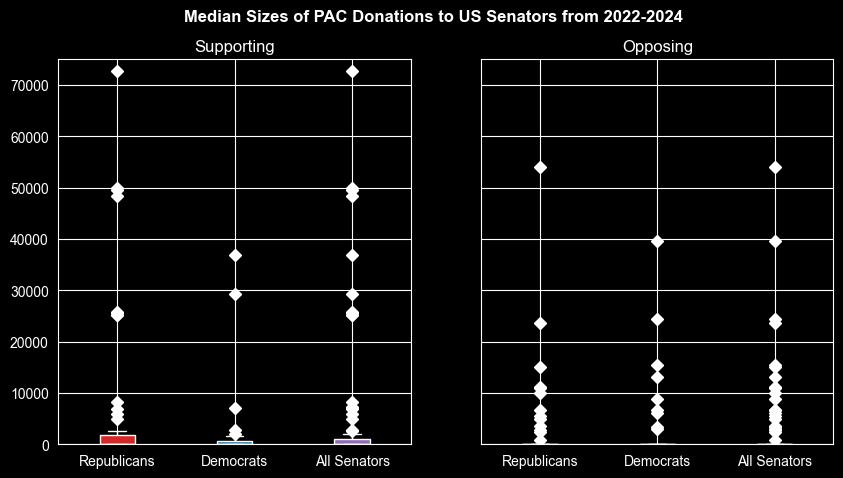

In [321]:
# to do: maybe make a boxplot, but show mean/median donation size for supporting and opposing
# maybe just need to remove all senators who did not get donations so it's more manageable
fig,axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

fig.suptitle("Median Sizes of PAC Donations to US Senators from 2022-2024", fontweight="bold")

all_supporting = current_senators_df["median supporting donation size"]
democratic_total_supporting = democratic_current_senators_df["median supporting donation size"]
republican_total_supporting = republican_current_senators_df["median supporting donation size"]

all_opposing = current_senators_df["median opposing donation size"]
democratic_total_opposing = democratic_current_senators_df["median opposing donation size"]
republican_total_opposing = republican_current_senators_df["median opposing donation size"]

supporting_sizes = [republican_total_supporting, democratic_total_supporting, all_supporting]
opposing_sizes = [republican_total_opposing, democratic_total_opposing, all_opposing]
labels = ["Republicans", "Democrats", "All Senators"]
colors = ["tab:red", "tab:blue", "tab:purple"]

plot1 = axs[0].boxplot(supporting_sizes, patch_artist=True, orientation="vertical", tick_labels=labels, sym='wD')

for patch, color in zip(plot1['boxes'], colors):
    patch.set_facecolor(color)
axs[0].set_title("Supporting")

plot2 = axs[1].boxplot(opposing_sizes, patch_artist=True, orientation="vertical", tick_labels=labels, sym='wD')

for patch, color in zip(plot2['boxes'], colors):
    patch.set_facecolor(color)
axs[1].set_title("Opposing")
axs[0].set_ylim(0, 75000)


plt.show()

All of the above are boxplots - not that you would be able to tell, on the opposing plots.  There are so many outliers that are so extreme, that the boxplots are almost entirely made of dots.  This, again, shows us that the distribution of PAC donations is very focused on a few senators.  This graph does allow us to study the outliers, though, and shows exactly how extreme they are.

As we saw in the pie chart, many senators did not receive any donations, and so, their median donation size is 0.  We are going to remove these senators in the next boxplot, to better show the distribution.

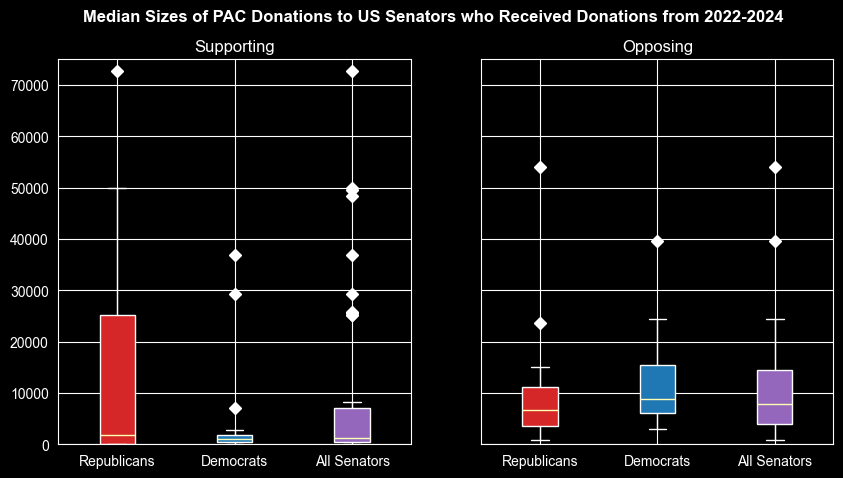

In [325]:
# fig,ax = plt.subplots()
# mask for removing candidates with no donations
all_supp = current_senators_df[current_senators_df["supporting donations received"] > 0]
all_opp = current_senators_df[current_senators_df["opposing donations received"] > 0]
# senators_with_donations_opp = current_senators_df["opposing donations received"] > 0
# ax.boxplot(received_donations_supp)
# ax = received_donations_supp["mean supporting donation size"].plot.hist(bins=20)
# # ax.boxplot(received_donations_supp["mean supporting donation size"])
# ax.set_title("Mean supporting donation size - senators with at least one donation")
# ax.set_ylabel("number of senators")
# ax.set_xlabel("mean donation size")
# # print(len(received_donations_supp))





fig,axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle("Median Sizes of PAC Donations to US Senators who Received Donations from 2022-2024", fontweight="bold")

all_supporting = all_supp["median supporting donation size"]
democratic_total_supporting = dem_sup_current["median supporting donation size"]
republican_total_supporting = rep_sup_current["median supporting donation size"]

all_opposing = all_opp["median opposing donation size"]
democratic_total_opposing = dem_opp_current["median opposing donation size"]
republican_total_opposing = rep_opp_current["median opposing donation size"]

supporting_sizes = [republican_total_supporting, democratic_total_supporting, all_supporting]
opposing_sizes = [republican_total_opposing, democratic_total_opposing, all_opposing]
labels = ["Republicans", "Democrats", "All Senators"]
colors = ["tab:red", "tab:blue", "tab:purple"]

plot1 = axs[0].boxplot(supporting_sizes, patch_artist=True, orientation="vertical", tick_labels=labels, sym='wD')

for patch, color in zip(plot1['boxes'], colors):
    patch.set_facecolor(color)
axs[0].set_title("Supporting")

plot2 = axs[1].boxplot(opposing_sizes, patch_artist=True, orientation="vertical", tick_labels=labels, sym='wD')

for patch, color in zip(plot2['boxes'], colors):
    patch.set_facecolor(color)
axs[1].set_title("Opposing")
axs[0].set_ylim(0, 75000)



plt.show()
# received_donations_supp.head(50)

With this (more readable) graph, we can see that, while there is still a heavy skew and at least one outlier on every graph, this skew is much more extreme for supporting donations.  One big difference is that the median supporting donation sizes received by democratic senators is, with only three exceptions, less than 5,000 dollars, while the median supporting donation sizes for republican candidates are often much larger than that.  This trend of democratic senators receiving smaller donations does not continue into opposing donations.  They tend to receive larger opposing donation sizes than republicans, but the difference is much less extreme than what we have observed with all 2022-2024 senate candidates in our main dataset.

#### PAC donations and gender in the US Senate

One of the reasons we were so interested in comparing our data to the current Senate is that it allows us some extra insights that were not possible with our larger dataset - for example, with our much smaller list of candidates, it was possible to add the genders of each senator, and see if there was any correlation between PAC donations and gender.

Of course, this data is limited, especially because there are currently only 26 female senators.  

AttributeError: 'PlotAccessor' object has no attribute 'histogram'

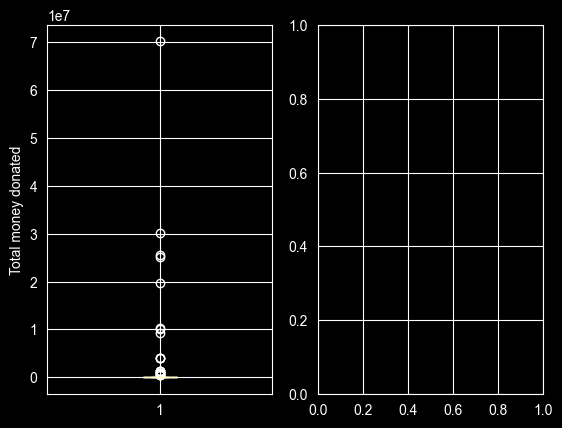

In [57]:
# total amount supporting boxplots
fig, axs = plt.subplots(1,2)
axs[0].boxplot(current_senators_df["sum of supporting donations"])
axs[0].set_ylabel("Total money donated")
axs[1] = current_senators_df.plot.histogram()
plt.show()

### Summary
With our preliminary results, Republicans received less money opposing them and more money supporting them. Democrats received more money opposing them and less money supporting them. There was a substantial amount of donations in our data totaling $1,365,559,640.